# Basic Data Visualization of SAILS data

In [85]:
EXCEL_PATH = "/orcd/data/satra/002/datasets/SAILS/data4analysis/Video Rating Data/SAILS_RATINGS_ALL_8.8.25.xlsx"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 160)

In [86]:
# Requires openpyxl
df = pd.read_excel(EXCEL_PATH, engine="openpyxl")

### Overview

In [87]:
print(f"Total Annotations: {len(df)}")
print(f"Unique Videos (SourceFile): {len(df["SourceFile"].unique())}")
print(f"Unique participants (ID): {df['ID'].nunique()}")
print("Attributes per Annotation:")
og_cols = df.columns
for col in og_cols:
    print(" -", col)

Total Annotations: 3902
Unique Videos (SourceFile): 3525
Unique participants (ID): 151
Attributes per Annotation:
 - Coder
 - SourceFile
 - ID
 - FileName
 - Vid_duration
 - DOB
 - Vid_date
 - Age_in_months
 - time_point
 - Context
 - Location
 - Activity
 - Child_of_interest_clear
 - #_adults
 - #_children
 - #_people_background
 - Interaction_with_child
 - #_people_interacting
 - Child_constrained
 - Constraint_type
 - Supports
 - Support_type
 - Example_support_type
 - Gestures
 - Gesture_type
 - Vocalizations
 - RMM
 - RMM_type
 - Response_to_name
 - Locomotion
 - Locomotion_type
 - Grasping
 - Grasp_type
 - Body_Parts_Visible
 - Angle_of_Body
 - Video_Quality_Child_Face_Visibility
 - Video_Quality_Child_Body_Visibility
 - Video_Quality_Child_Hand_Visibility
 - Video_Quality_Lighting
 - Video_Quality_Resolution
 - Video_Quality_Motion
 - Notes


In [88]:
dupes = df[df.duplicated(subset=["SourceFile"], keep=False)]
print("Videos with >1 annotation:", dupes["SourceFile"].nunique())

Videos with >1 annotation: 377


In [89]:
cols_to_check = [
    "Activity",
    "Interaction_with_child",
    "#_people_interacting",
    "Child_constrained",
    "Constraint_type",
    "Supports",
    "Support_type",
    "Example_support_type",
    "Gestures",
    "Gesture_type",
    "Vocalizations",
    "RMM",
    "RMM_type",
    "Response_to_name",
    "Locomotion",
    "Locomotion_type",
    "Grasping",
    "Grasp_type",
    "time_point"
]

for col in cols_to_check:
    uniques = df[col].dropna().unique()
    print(f"\n--- {col} ---")
    print(uniques[:50])
    print(f"Total unique (incl. NaN): {df[col].nunique(dropna=False)}")


--- Activity ---
['Child is eating apples in a high chair'
 'Child is playing with books while adult speaks to them'
 'Child is playing with a spining toy with adult'
 'child is playing with a light up ball'
 'Child is walking around house and is eventually picked up by adult in bed'
 'Child is playing with octopus toy with adult'
 'Child is being held by an adult to push a stroller'
 'Child is being held by an adult on a train'
 'Child is drinking water with the help of an adult'
 'Child is smiling while on top of a bed'
 'Child is poking adult in the eye' 'Child is taking a book off the shelf'
 'Child is playing with toy while adult is talking '
 'Child is playing with a ball' 'Child is playing with and biting a book'
 'Child is crying while adult speaks to them'
 'Child picks and is read a book'
 'Child is placing mouth on various objects and leg'
 'Child is flipping though pages of book without being read to or playing'
 'Child is walking on sidewalk'
 'Adult is speaking to child 

In [90]:
categorical_cols = [
    "Interaction_with_child",
    "#_people_interacting",
    "Child_constrained",
    "Constraint_type",
    "Supports",
    "Support_type",
    "Gestures",
    "Gesture_type",
    "Vocalizations",
    "RMM",
    "RMM_type",
    "Response_to_name",
    "Locomotion",
    "Locomotion_type",
    "Grasping",
    "Grasp_type",
    "time_point"
]

free_text_cols = ["Activity", "Example_support_type"]

# categorical summaries
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))

# free-text: show top frequent strings
for col in free_text_cols:
    print(f"\n--- {col} (free-text, top 15) ---")
    print(df[col].value_counts().head(15))


--- Interaction_with_child ---
Interaction_with_child
yes    2955
no      853
NaN      94
Name: count, dtype: int64

--- #_people_interacting ---
#_people_interacting
1      2360
0       859
2       469
NaN      94
3        61
5+       32
+        15
4        10
5         2
Name: count, dtype: int64

--- Child_constrained ---
Child_constrained
no         2955
yes         703
partial     145
NaN          95
no            4
Name: count, dtype: int64

--- Constraint_type ---
Constraint_type
NaN                    3056
high chair              205
highchair                53
car seat                 47
being held               46
held                     43
body held/picked up      39
high chair               24
carseat                  16
in lap                   16
swing                    14
held by caregiver        12
booster seat             12
playpen                  11
chair                    10
Name: count, dtype: int64

--- Supports ---
Supports
yes    2623
no     1184
NaN      

In [91]:
# df.loc[df["Example_support_type"]=="\"what are you doing?\""]
# df.loc[df["RMM_type"]=="jumping"]
# df.loc[df["ID"]=="C1I8N8L4Q4"][["SourceFile","RMM_type"]]

### Investigating missing time_point

In [92]:
no_time_point = df.loc[df["time_point"].isna()]
no_time_point

,Coder,SourceFile,ID,FileName,Vid_duration,DOB,Vid_date,Age_in_months,time_point,Context,...,Grasp_type,Body_Parts_Visible,Angle_of_Body,Video_Quality_Child_Face_Visibility,Video_Quality_Child_Body_Visibility,Video_Quality_Child_Hand_Visibility,Video_Quality_Lighting,Video_Quality_Resolution,Video_Quality_Motion,Notes
35,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/8-7-2019.MOV,C1I8N8L4Q4,8-7-2019.MOV,00:00:13.500000,2016-03-20,2019-08-07 00:00:00,40.580464,NaN,motor play,...,whole hand,both,variable,2.0,9.0,3.0,10.0,10.0,9.0,Locomotion-Climbing up
36,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/9-29-2019.mp4,C1I8N8L4Q4,9-29-2019.mp4,00:00:12.700000,2016-03-20,2019-10-10 00:00:00,42.683136,NaN,toy play,...,whole hand,both,variable,3.0,8.0,2.0,10.0,8.0,8.0,NaN
37,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/9-30-2019.MOV,C1I8N8L4Q4,9-30-2019.MOV,00:00:11.500000,2016-03-20,2019-09-30 00:00:00,42.354593,NaN,general social communication interaction,...,NaN,upper,front,2.0,1.0,2.0,2.0,9.0,9.0,NaN
38,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/06-03-2019.mp4,C1I8N8L4Q4,06-03-2019.mp4,00:00:31.200000,2016-03-20,2019-10-29 00:00:00,43.307366,NaN,general social communication interaction,...,whole hand,both,variable,4.0,5.0,3.0,10.0,10.0,7.0,NaN
39,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/05-13-2019.mp4,C1I8N8L4Q4,05-13-2019.mp4,00:00:13.900000,2016-03-20,2019-11-25 00:00:00,44.195800,NaN,general social communication interaction,...,NaN,upper,front,7.0,6.0,4.0,9.0,9.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/N.T._Home_Videos_AMES_B9P5V1I5O5/12-16 month videos/IMG_8205.mov,B9P5V1I5O5,IMG_8205.mov,00:00:59.600000,2015-01-22,2016-10-01 00:00:00,20.309397,NaN,motor play,...,NaN,both,variable,5.0,7.0,4.0,10.0,10.0,6.0,NaN
3884,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/N.T._Home_Videos_AMES_B9P5V1I5O5/12-16 month videos/IMG_8206.mov,B9P5V1I5O5,IMG_8206.mov,00:00:17.500000,2015-01-22,2016-10-01 00:00:00,20.309397,NaN,motor play,...,pincer,both,front,8.0,9.0,8.0,8.0,10.0,7.0,NaN
3885,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/N.T._Home_Videos_AMES_B9P5V1I5O5/12-16 month videos/IMG_8381.mov,B9P5V1I5O5,IMG_8381.mov,00:00:22.900000,2015-01-22,2016-10-31 00:00:00,21.295024,NaN,daily routine,...,multiple,both,profile,7.0,9.0,6.0,10.0,10.0,9.0,NaN
3886,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/N.T._Home_Videos_AMES_B9P5V1I5O5/12-16 month videos/IMG_8433.mov,B9P5V1I5O5,IMG_8433.mov,00:00:15.300000,2015-01-22,2016-11-08 00:00:00,21.559227,NaN,social routine,...,pincer,upper,front,9.0,6.0,6.0,10.0,10.0,9.0,NaN


In [93]:
mask_timepoint = (df["SourceFile"].str.contains("month videos", case=False, na=False) | df["SourceFile"].str.contains("month home videos", case=False, na=False))

df_timepoint    = no_time_point[mask_timepoint]
no_time_point[~mask_timepoint]

/tmp/ipykernel_124582/2823618946.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_timepoint    = no_time_point[mask_timepoint]
/tmp/ipykernel_124582/2823618946.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  no_time_point[~mask_timepoint]


,Coder,SourceFile,ID,FileName,Vid_duration,DOB,Vid_date,Age_in_months,time_point,Context,...,Grasp_type,Body_Parts_Visible,Angle_of_Body,Video_Quality_Child_Face_Visibility,Video_Quality_Child_Body_Visibility,Video_Quality_Child_Hand_Visibility,Video_Quality_Lighting,Video_Quality_Resolution,Video_Quality_Motion,Notes
1062,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_K8F9J9J1I2/12-16 months/Screen_Recording_20230816_135939_Instagram.mp4,K8F9J9J1I2,Screen_Recording_20230816_135939_Instagram.mp4,00:00:09.400000,2015-09-18,2023-08-16 00:00:00,94.921380,NaN,daily routine,...,multiple,upper,front,9.0,9.0,9.0,10.0,9.0,9.0,NaN
1063,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_K8F9J9J1I2/12-16 months/Screen_Recording_20230816_140109_Instagram.mp4,K8F9J9J1I2,Screen_Recording_20230816_140109_Instagram.mp4,00:00:58.300000,2015-09-18,2023-08-16 00:00:00,94.921380,NaN,motor play,...,whole hand,both,variable,7.0,8.0,6.0,9.0,9.0,6.0,NaN
1064,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_K8F9J9J1I2/12-16 months/Screen_Recording_20230816_140316_Instagram.mp4,K8F9J9J1I2,Screen_Recording_20230816_140316_Instagram.mp4,00:01:05.700000,2015-09-18,2023-08-16 00:00:00,94.921380,NaN,motor play,...,NaN,both,variable,6.0,8.0,6.0,10.0,9.0,9.0,switches between videos on screen recording
1065,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_K8F9J9J1I2/12-16 months/Screen_Recording_20230816_140638_Instagram.mp4,K8F9J9J1I2,Screen_Recording_20230816_140638_Instagram.mp4,00:02:57.300000,2015-09-18,2023-08-16 00:00:00,94.921380,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cannot rate as one video-multiple videos in one screen recording
1066,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_K8F9J9J1I2/34-38 months/Screen_Recording_20230816_141424_Instagram.mp4,K8F9J9J1I2,Screen_Recording_20230816_141424_Instagram.mp4,00:05:12.700000,2015-09-18,2023-08-16 00:00:00,94.921380,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cannot rate as one video-multiple videos in one screen recording
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3845,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.G._Home_Videos_AMES_K7C7T5A2H9/06-13-2017.MOV,K7C7T5A2H9,06-13-2017.MOV,00:00:51.400000,2014-02-25,2017-06-13 00:00:00,39.561983,NaN,book share,...,NaN,upper,variable,3.0,4.0,9.0,3.0,8.0,8.0,NaN
3846,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.G._Home_Videos_AMES_K7C7T5A2H9/09-20-2016.MOV,K7C7T5A2H9,09-20-2016.MOV,00:01:23.400000,2014-02-25,2016-09-20 00:00:00,30.822755,NaN,toy play,...,multiple,both,variable,4.0,6.0,6.0,10.0,10.0,8.0,NaN
3847,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.G._Home_Videos_AMES_K7C7T5A2H9/10-26-2017.MOV,K7C7T5A2H9,10-26-2017.MOV,00:00:22,2014-02-25,2017-10-26 00:00:00,43.997306,NaN,general social communication interaction,...,whole hand,both,front,9.0,7.0,4.0,10.0,10.0,9.0,NaN
3848,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.G._Home_Videos_AMES_K7C7T5A2H9/11-15-2016.MOV,K7C7T5A2H9,11-15-2016.MOV,00:00:16.700000,2014-02-25,2016-11-15 00:00:00,32.663961,NaN,toy play,...,whole hand,upper,front,9.0,6.0,8.0,6.0,9.0,9.0,NaN


In [94]:
# no_time_point.loc[no_time_point["SourceFile"].str.count("/") == 7]
df["slash_count"] = no_time_point["SourceFile"].str.count("/")
slash_group = df.groupby("slash_count")
print(slash_group.size())
slash_group[["SourceFile", "slash_count"]].head(15)

slash_count
6.0     33
7.0    724
8.0     30
dtype: int64


,SourceFile,slash_count
35,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/8-7-2019.MOV,7.0
36,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/9-29-2019.mp4,7.0
37,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/9-30-2019.MOV,7.0
38,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/06-03-2019.mp4,7.0
39,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/05-13-2019.mp4,7.0
40,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/12-16 month videos/3.3.17.mp4,7.0
41,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/12-16 month videos/09-04-2017.mp4,7.0
42,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/12-16 month videos/09-17-2017.MOV,7.0
43,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/12-16 month videos/10-28-2017.MOV,7.0
44,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/12-16 month videos/11-17-2017.MOV,7.0


In [95]:
print(no_time_point.loc[df["slash_count"] == 6].groupby("ID").size())
print(no_time_point.loc[df["slash_count"] == 7].groupby("ID").size())
print(no_time_point.loc[df["slash_count"] == 8].groupby("ID").size())

ID
D4Y7P4G2V4    3
K7C7T5A2H9    6
M4R4B8C7G8    6
M5F7G8S4F0    1
O7X6W5O8E0    4
R6G4I3H3J0    3
U6O5F2B7T5    2
V7D7K3H8B4    8
dtype: int64
ID
A2L1R9Y7C8     2
A2M5H0V6E3     6
A2P7X9N8L7     2
A3G3T7I1A5     1
A5S7G5T0S5     3
              ..
Z3C2V9T0V1    11
Z3H6O7C3O9     2
Z6Z0I5G6A6     7
Z7I5F2E1L4     2
Z9B5P1T0P8     3
Length: 106, dtype: int64
ID
A6Y4Y7X2G1     2
B2R3Q8L2Y3     3
H7B1M3P5D9    19
S4C2W1M7Q0     6
dtype: int64


In [103]:
mask_timepoint = (no_time_point["SourceFile"].str.contains("12-16", case=False, na=False) | no_time_point["SourceFile"].str.contains("34-38", case=False, na=False))
df.loc[~df["slash_count"].isna()][~mask_timepoint][["SourceFile", "slash_count"]]
# no_time_point.loc[df["slash_count"] == 7][~mask_timepoint]

,SourceFile,slash_count
50,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.L._Home_Videos_AMES_Z7I5F2E1L4/34-28 month videos/IMG_8552.mov,7.0
51,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.L._Home_Videos_AMES_Z7I5F2E1L4/34-28 month videos/IMG_8614.mov,7.0
1130,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/E.R._Home_Videos_AMES_M5F7G8S4F0/IMG_4408.mov,6.0
1347,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/M.S._Home_Videos_AMES_M4R4B8C7G8/10-19-2019.mov,6.0
1349,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/M.S._Home_Videos_AMES_M4R4B8C7G8/4-30-2021.mov,6.0
1352,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/M.S._Home_Videos_AMES_M4R4B8C7G8/5-7-2021.mov,6.0
3531,/Volumes/T7 Shield/AMES_Phase_III/vid_check_liz/D.B._Home_Videos_AMES_V7D7K3H8B4/IMG_6169.MOV,6.0
3532,/Volumes/T7 Shield/AMES_Phase_III/vid_check_liz/D.B._Home_Videos_AMES_V7D7K3H8B4/IMG_6170.MOV,6.0
3533,/Volumes/T7 Shield/AMES_Phase_III/vid_check_liz/D.B._Home_Videos_AMES_V7D7K3H8B4/IMG_7719.MOV,6.0
3534,/Volumes/T7 Shield/AMES_Phase_III/vid_check_liz/D.B._Home_Videos_AMES_V7D7K3H8B4/IMG_7726.MOV,6.0


In [104]:
df["assumed_time_point"] = df["time_point"]

# fill NA rows with rules based on SourceFile
mask_na = df["assumed_time_point"].isna()

df.loc[mask_na & df["SourceFile"].str.contains("12-16", na=False),
       "assumed_time_point"] = "14_month"

df.loc[mask_na & df["SourceFile"].str.contains("34-38|34-28", na=False),
       "assumed_time_point"] = "36_month"

In [107]:
print(df.groupby("assumed_time_point").size())
print(df["assumed_time_point"].value_counts(dropna=False))

assumed_time_point
14_month    2004
36_month    1865
dtype: int64
assumed_time_point
14_month    2004
36_month    1865
NaN           33
Name: count, dtype: int64


### Data Cleaning

In [108]:
# --- Helpers ---

def strip_strings(df, cols=None):
    """Strip whitespace and standardize empty-like strings to NaN for object columns."""
    if cols is None:
        cols = df.select_dtypes(include=["object"]).columns.tolist()
    for c in cols:
        df[c] = (df[c].astype(str)
                    .str.strip()
                    .replace({"": np.nan, "nan": np.nan, "None": np.nan}))
    return df

def coerce_datetime(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def coerce_time_to_seconds(series):
    """Convert pandas/datetime.time-like durations to seconds (float)."""
    out = []
    for v in series:
        if pd.isna(v):
            out.append(np.nan)
            continue
        if hasattr(v, "hour"):
            # datetime.time or Timestamp
            seconds = v.hour*3600 + v.minute*60 + v.second + (getattr(v, "microsecond", 0) or 0)/1e6
            out.append(seconds)
        else:
            # try parse generic
            try:
                out.append(pd.to_timedelta(v).total_seconds())
            except Exception:
                out.append(np.nan)
    return pd.Series(out, index=series.index)

def to_numeric_lower_bound(x):
    """
    Numeric feature for analysis:
    - '5+' -> 5   (lower bound)
    - '10+' -> 10
    - '+' -> NaN  (ambiguous)
    - digits -> int
    - other/NaN -> NaN
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.isdigit():
        return int(s)
    if s.endswith("+") and s[:-1].isdigit():
        return int(s[:-1])
    return np.nan

def to_viz_bin(x, collapse_high_at=None):
    """
    Categorical feature for plotting:
    - digits -> keep as string, but if collapse_high_at is set and value >= threshold -> '≥{threshold}'
    - 'd+' -> '≥d'
    - '+'  -> 'Unknown+'
    - NaN  -> NaN
    - other strings -> keep (as-is)
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    # 'd+' -> '≥d'
    if s.endswith("+") and s[:-1].isdigit():
        return f"≥{int(s[:-1])}"
    if s == "+":
        return "Unknown (+)"
    # plain digits
    if s.isdigit():
        v = int(s)
        if collapse_high_at is not None and v >= collapse_high_at:
            return f"≥{int(collapse_high_at)}"
        return str(v)
    return s  # leave other labels as-is

def make_numeric_and_plot_bins(df, col, collapse_high_at=None):
    """
    Creates two new columns:
    - <col>_num  : numeric lower-bound version (for stats)
    - <col>_plot : categorical-binned version (for visualization)
    """
    num_col = f"{col}_num"
    plot_col = f"{col}_plot"
    df[num_col] = df[col].map(to_numeric_lower_bound)
    df[plot_col] = df[col].map(lambda x: to_viz_bin(x, collapse_high_at=collapse_high_at))
    return num_col, plot_col

def standardize_categories(df):
    """Fix common typos/variants and harmonize categories."""
    replace_map = {
        # Locations
        "outside oublic": "outside public",
        "outside public ": "outside public",
        "outside private ": "outside private",
        "inside public ": "inside public",
        "inside private ": "inside private",
        "unknown ": "unknown",
        # time_point
        "14_month ": "14_month",
        "36_month ": "36_month",
        # booleans/yes-no fields
        "yes ": "yes",
        "no ": "no",
        "n/a ": "n/a",
        # gestures
        "mutiple": "multiple",
        "clapping": "clap",
        "reach ": "reach",
        # body parts
        "both ": "both",
        # angle
        "front ": "front",
        "variable ": "variable",
        # locomotion type
        "walk ": "walk",
        "crawl ": "crawl",
        # constraint type
        "highchair": "high chair",
        #support type
        "verbal ": "verbal",
        #grasp type
        "whole hand ": "whole hand "
    }
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].replace(replace_map)
    return df

def coerce_quality_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def to_categorical(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
    return df

In [109]:
# --- Cleaning ---

df = strip_strings(df)

# harmonize common categorical variants
df = standardize_categories(df)

# Parse datetime columns
datetime_cols = ["DOB", "Vid_date"]
df = coerce_datetime(df, datetime_cols)

# Duration to seconds
if "Vid_duration" in df.columns:
    df["Vid_duration_s"] = coerce_time_to_seconds(df["Vid_duration"])

# Coerce count-like columns that may contain '10+' or '+'
count_cols = ["#_adults", "#_children", "#_people_background", "#_people_interacting"]
for c in count_cols:
    if c in df.columns:
        make_numeric_and_plot_bins(df, c)
        # df[c + "_num"] = df[c].apply(make_numeric_and_plot_bins)

# Coerce video quality metrics to numeric
quality_cols = [
    "Video_Quality_Child_Face_Visibility",
    "Video_Quality_Child_Body_Visibility",
    "Video_Quality_Child_Hand_Visibility",
    "Video_Quality_Lighting",
    "Video_Quality_Resolution",
    "Video_Quality_Motion",
]
df = coerce_quality_numeric(df, quality_cols)

# Ensure expected categorical columns are categories
cat_cols = [
    "time_point","Context","Location","Activity","Child_of_interest_clear",
    "Interaction_with_child","Child_constrained","Constraint_type",
    "Supports","Support_type","Gestures","Gesture_type","Vocalizations",
    "RMM","RMM_type","Response_to_name","Locomotion","Locomotion_type",
    "Grasping","Grasp_type","Body_Parts_Visible","Angle_of_Body","Coder"
]
df = to_categorical(df, [c for c in cat_cols if c in df.columns])

# Recompute Age_in_months if missing and DOB/Vid_date available
if "Age_in_months" in df.columns:
    mask_missing_age = df["Age_in_months"].isna() & df["DOB"].notna() & df["Vid_date"].notna()
    if mask_missing_age.any():
        delta_days = (df.loc[mask_missing_age, "Vid_date"] - df.loc[mask_missing_age, "DOB"]).dt.days
        df.loc[mask_missing_age, "Age_in_months"] = delta_days / 30.44

print("After cleaning:", df.shape)
df.head()

After cleaning: (3902, 53)


,Coder,SourceFile,ID,FileName,Vid_duration,DOB,Vid_date,Age_in_months,time_point,Context,...,assumed_time_point,Vid_duration_s,#_adults_num,#_adults_plot,#_children_num,#_children_plot,#_people_background_num,#_people_background_plot,#_people_interacting_num,#_people_interacting_plot
0,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-02-2018.MOV,A6Y4Y7X2G1,12-02-2018.MOV,00:00:10,2017-10-31,2018-12-19,13.608501,14_month,daily routine,...,14_month,10.0,0.0,0,1.0,1,0.0,0,0.0,0
1,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-09-2018.MOV,A6Y4Y7X2G1,12-09-2018.MOV,00:00:35.100000,2017-10-31,2018-12-12,13.378521,14_month,toy play,...,14_month,35.1,0.0,0,1.0,1,0.0,0,1.0,1
2,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-11-2018.MOV,A6Y4Y7X2G1,12-11-2018.MOV,00:01:40.400000,2017-10-31,2018-12-28,13.904189,14_month,toy play,...,14_month,100.4,1.0,1,1.0,1,0.0,0,1.0,1
3,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-22-2018.MOV,A6Y4Y7X2G1,12-22-2018.MOV,00:00:15.400000,2017-10-31,2018-12-22,13.707063,14_month,toy play,...,14_month,15.4,0.0,0,1.0,1,0.0,0,1.0,1
4,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Dec 2018 (14m)/12-29-2018.MOV,A6Y4Y7X2G1,12-29-2018.MOV,00:01:01.200000,2017-10-31,2018-12-20,13.641355,14_month,general social communication interaction,...,14_month,61.2,0.0,0,1.0,1,1.0,1,2.0,2


### Reports

In [110]:
# --- Availablity ---
n = len(df)

pct_avail = df[og_cols].notna().mean() * 100
count_avail = df[og_cols].notna().sum()

avail_df = pd.DataFrame({
    "Attribute": pct_avail.index,
    "Availability (%)": pct_avail.values,
    "Count": count_avail.values
}).sort_values("Availability (%)", ascending=False)

avail_df

,Attribute,Availability (%),Count
0,Coder,100.000000,3902
1,SourceFile,100.000000,3902
2,ID,100.000000,3902
3,FileName,100.000000,3902
5,DOB,100.000000,3902
4,Vid_duration,99.846233,3896
9,Context,97.590979,3808
16,Interaction_with_child,97.590979,3808
13,#_adults,97.590979,3808
10,Location,97.590979,3808


In [111]:
# --- Numeric summaries ---
exclude = ["Age_in_months"] 
numeric_cols = df.drop(columns=exclude).select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Video_Quality_Child_Face_Visibility,3807.0,6.415025,2.660421,1.0,4.0,7.0,9.0,10.0
Video_Quality_Child_Body_Visibility,3806.0,7.710457,1.885621,1.0,7.0,8.0,9.0,10.0
Video_Quality_Child_Hand_Visibility,3777.0,5.837437,2.175569,1.0,5.0,6.0,8.0,10.0
Video_Quality_Lighting,3777.0,9.683876,1.066456,1.0,10.0,10.0,10.0,10.0
Video_Quality_Resolution,3777.0,9.791898,0.792983,1.0,10.0,10.0,10.0,10.0
Video_Quality_Motion,3777.0,7.667726,1.671039,1.0,7.0,8.0,9.0,10.0
slash_count,787.0,6.996188,0.283087,6.0,7.0,7.0,7.0,8.0
Vid_duration_s,3896.0,40.583214,49.886752,0.1,15.5,27.9,48.5,1036.8
#_adults_num,3808.0,0.304359,0.660382,0.0,0.0,0.0,1.0,10.0
#_children_num,3808.0,1.281250,0.776558,0.0,1.0,1.0,1.0,10.0


### Visualizations

In [143]:
def _order_for_plot(idx):
    """
    Order categories:
    - numeric strings ascending (e.g., '0','1','2',...)
    - then '≥k' ascending by k
    - then other strings alphabetically
    """
    nums, ge, other = [], [], []
    for v in idx:
        m_ge = re.fullmatch(r"≥(\d+)", str(v))
        if isinstance(v, str) and v.isdigit():
            nums.append((int(v), v))
        elif m_ge:
            ge.append((int(m_ge.group(1)), v))
        else:
            other.append((str(v), v))
    ordered = [v for _, v in sorted(nums, key=lambda x: x[0])]
    ordered += [v for _, v in sorted(ge, key=lambda x: x[0])]
    ordered += [v for _, v in sorted(other, key=lambda x: x[0])]
    return ordered

def plot_bar_with_percent(series, title=None):
    """
    Bar chart with % labels and NaN kept as a bar.
    - Orders numeric-like categories logically.
    """
    vc = series.value_counts(dropna=False)
    # Convert NaN index to string 'NaN' for plotting
    vc.index = vc.index.map(lambda x: "NaN" if pd.isna(x) else x)

    # Order categories nicely
    order = _order_for_plot(vc.index)
    vc = vc.reindex(order)

    pct = vc / len(series) * 100

    plt.figure(figsize=(8,6))
    ax = vc.plot(kind="bar", edgecolor="black")
    plt.title(title or series.name)
    plt.xlabel(series.name or "")
    plt.ylabel("Count")
    for i, (count, p) in enumerate(zip(vc, pct)):
        if np.isnan(count):  # safety
            continue
        ax.text(i, count + (0.01 * vc.max() if vc.max() > 0 else 0.5), f"{p:.1f}%", ha="center")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def _prep_counts(series):
    """Return value counts (incl. NaN as 'NaN') and same index order."""
    vc = series.value_counts(dropna=False)
    vc.index = vc.index.map(lambda x: "NaN" if pd.isna(x) else x)
    order = _order_for_plot(vc.index)
    vc = vc.reindex(order)
    return vc
    
def plot_by_time_point(
    df,
    col,
    by_prop=False,
    time_col="time_point",
    left_label="14_month",
    right_label="36_month",
    title=None
):
    """
    Side-by-side bar plots of `col` split by `time_col` (default: 14 vs 36 months).
    Shows counts with percentage labels (percent within each time split).
    Keeps NaN as its own bar and orders categories like plot_bar_with_percent.
    """
    # split
    left_df  = df[df[time_col] == left_label]
    right_df = df[df[time_col] == right_label]

    # value counts (ordered) for each side
    vc_left  = _prep_counts(left_df[col])
    vc_right = _prep_counts(right_df[col])

    # union of indices so both sides share same x categories
    all_idx = list(dict.fromkeys(list(vc_left.index) + list(vc_right.index)))
    vc_left  = vc_left.reindex(all_idx).fillna(0)
    vc_right = vc_right.reindex(all_idx).fillna(0)

    # percents within each split
    pct_left  = (vc_left / len(left_df[col])) * 100 if len(left_df)  else vc_left*0
    pct_right = (vc_right / len(right_df[col])) * 100 if len(right_df) else vc_right*0

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, vc, pct, label in [(axes[0], vc_left, pct_left, left_label),
                               (axes[1], vc_right, pct_right, right_label)]:
        plot_val = pct if by_prop else vc
        plot_val.plot(kind="bar", edgecolor="black", ax=ax)
        ax.set_title(f"{label}")
        ax.set_xlabel(col)
        ax.set_ylabel("Proportion" if by_prop else "Count")
        ymax = plot_val.max()
        for i, (count, p) in enumerate(zip(vc, pct)):
            if by_prop:
                ax.text(i, p + (0.01 * ymax if ymax > 0 else 0.5), f"{count}", ha="center")
            else:
                ax.text(i, count + (0.01 * ymax if ymax > 0 else 0.5), f"{p:.1f}", ha="center")
        ax.tick_params(axis="x", rotation=45)
        ax.margins(x=0.02)

    suptitle = title or f"{col} by {time_col}"
    fig.suptitle(suptitle, y=1.03)
    plt.tight_layout()
    plt.show()

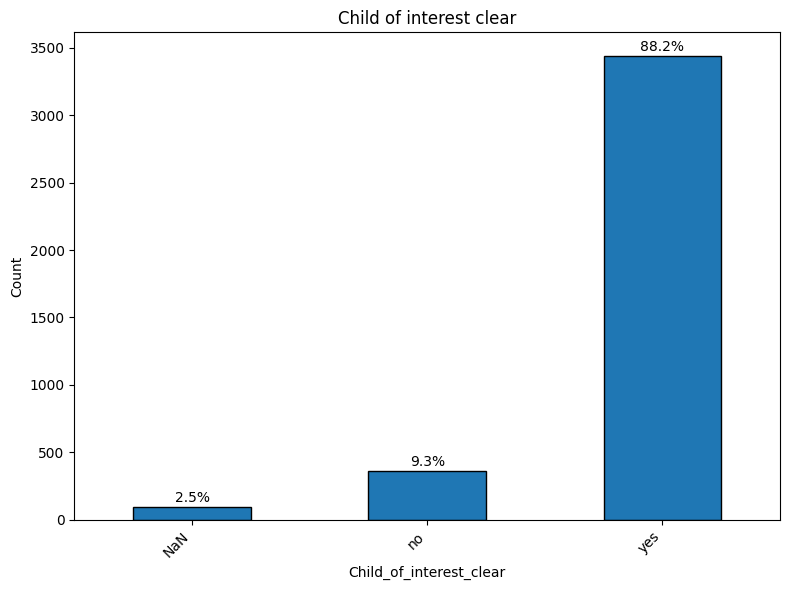

In [138]:
plot_bar_with_percent(df["Child_of_interest_clear"], title="Child of interest clear")

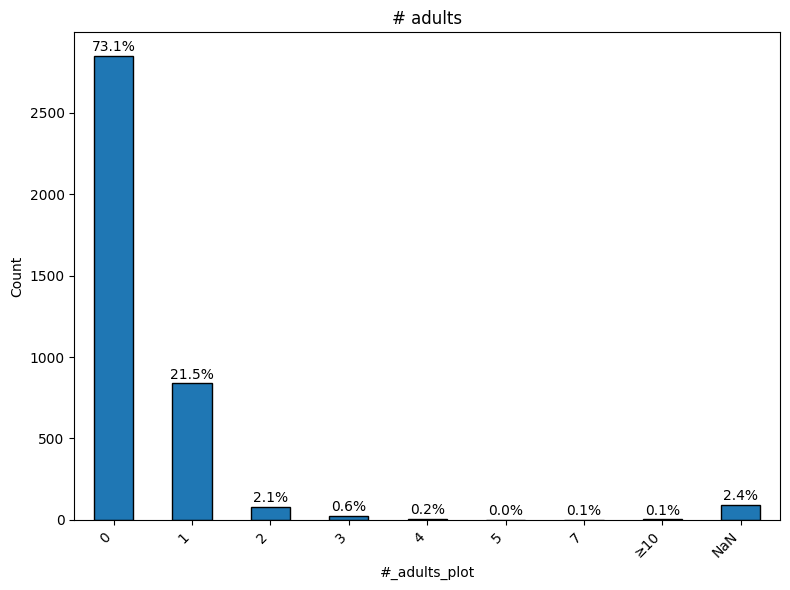

In [114]:
plot_bar_with_percent(df["#_adults_plot"], title="# adults")

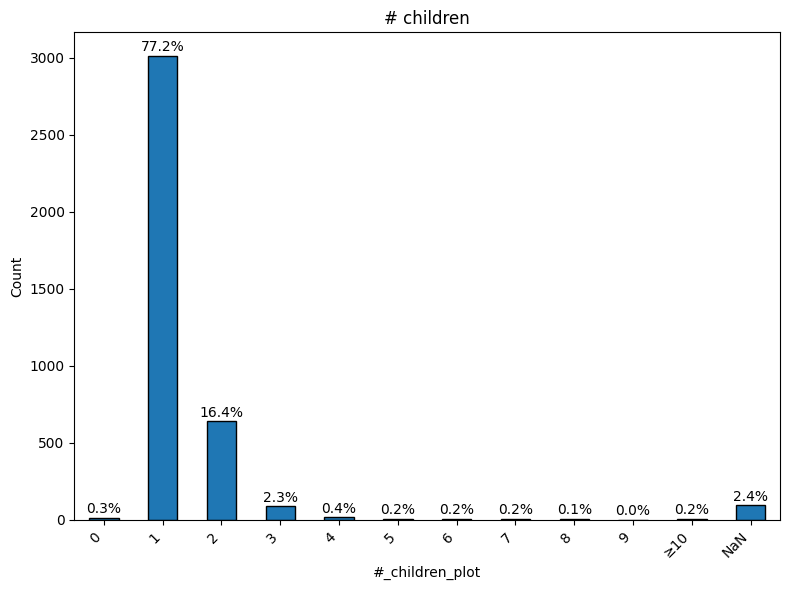

In [115]:
plot_bar_with_percent(df["#_children_plot"], title="# children")

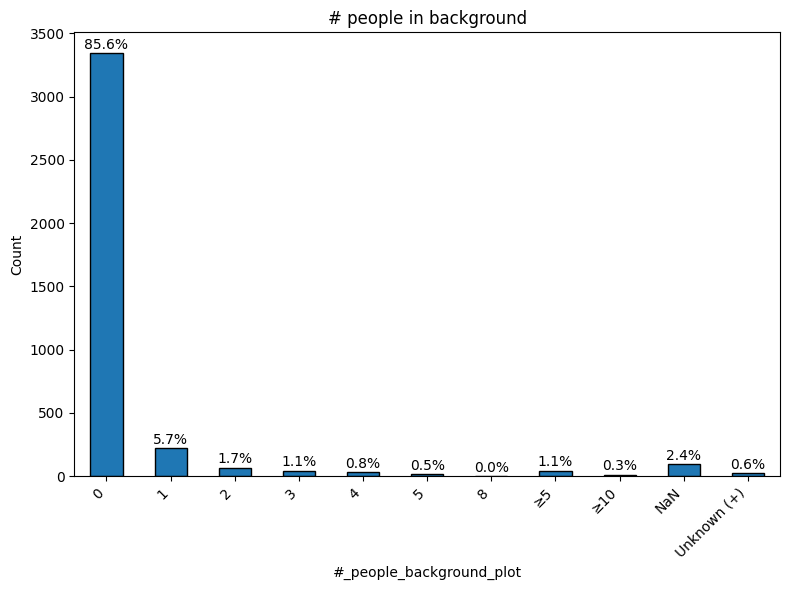

In [116]:
plot_bar_with_percent(df["#_people_background_plot"], title="# people in background")

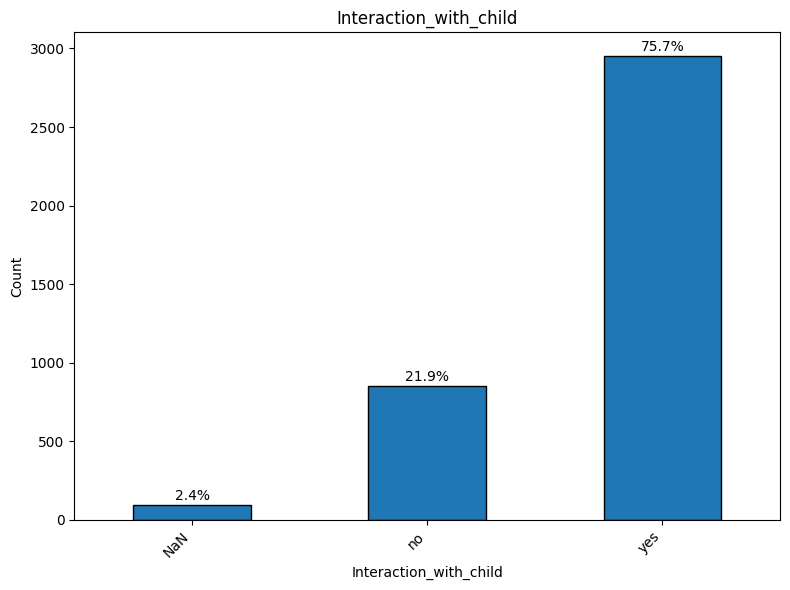

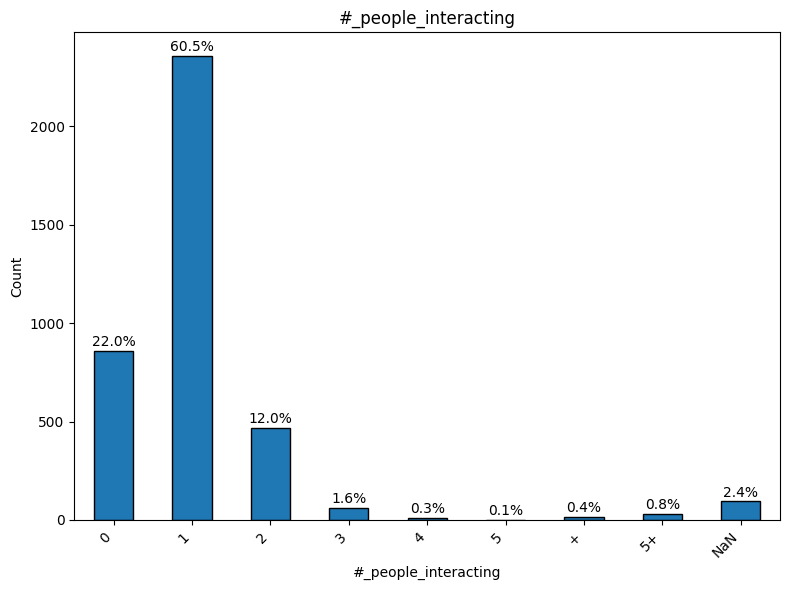

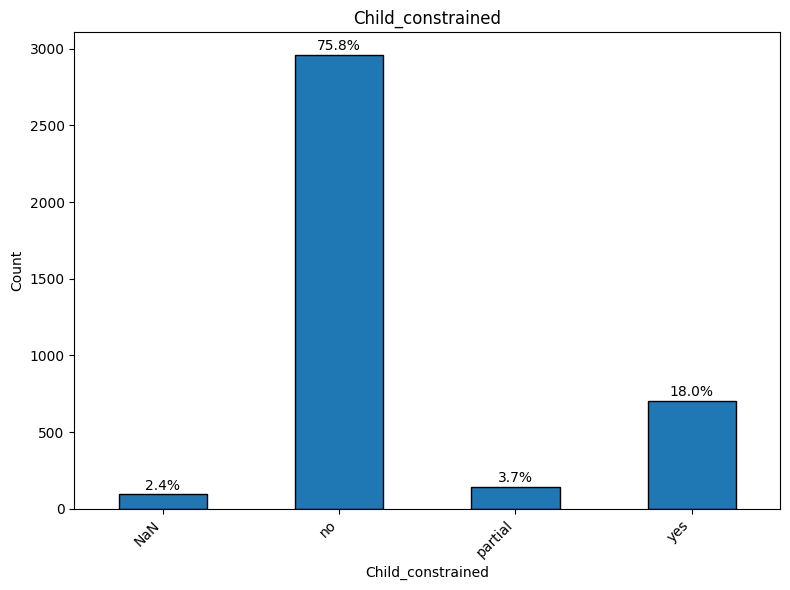

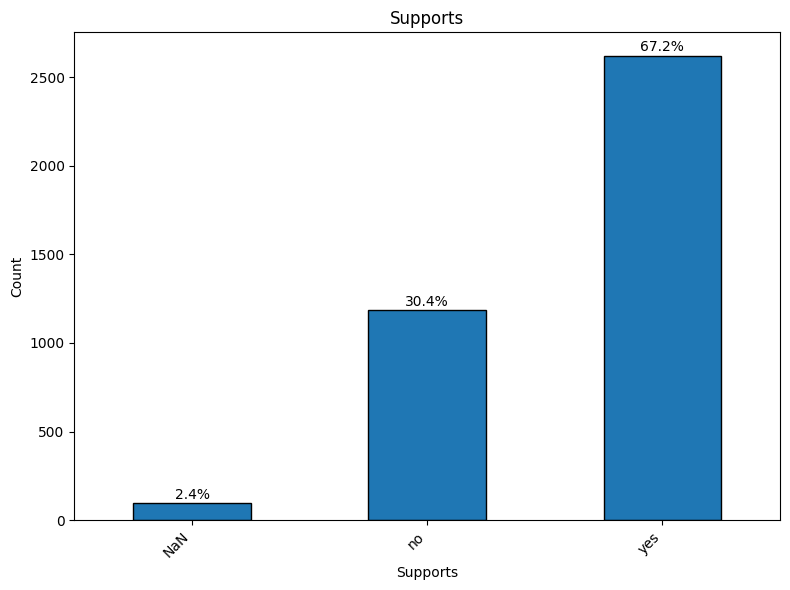

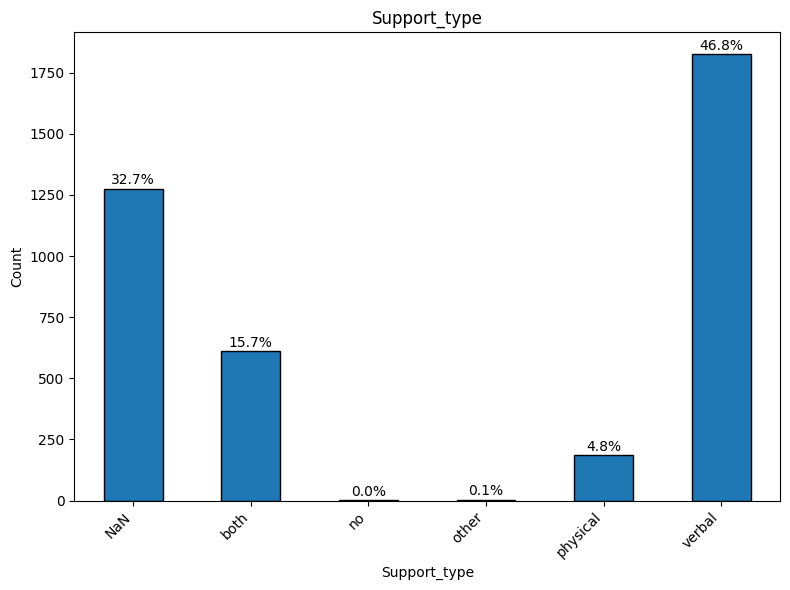

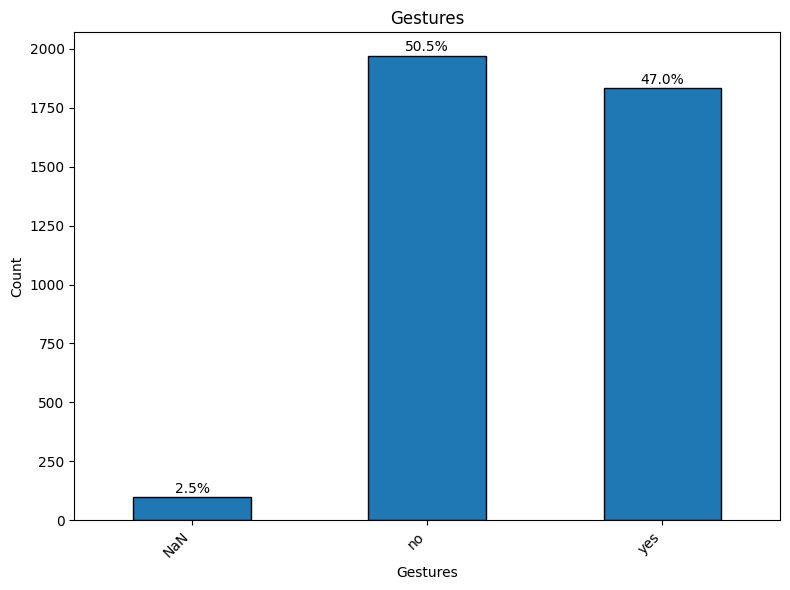

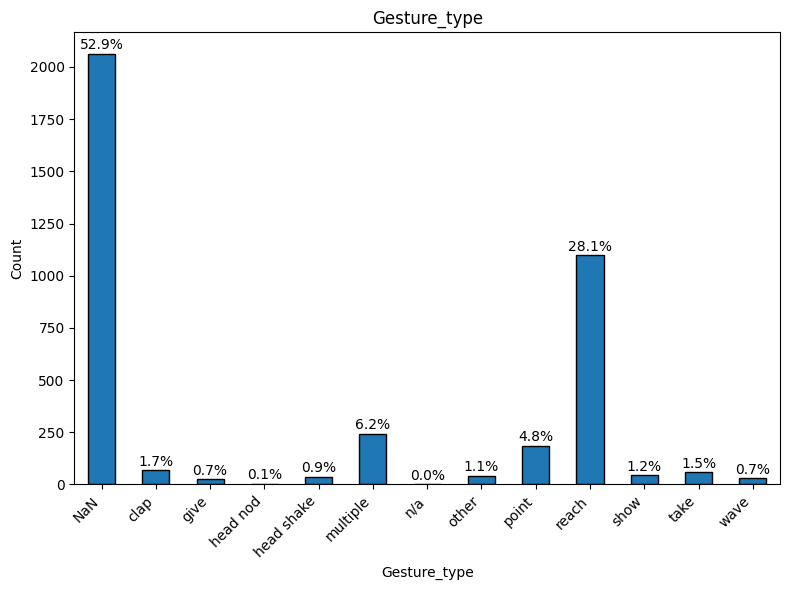

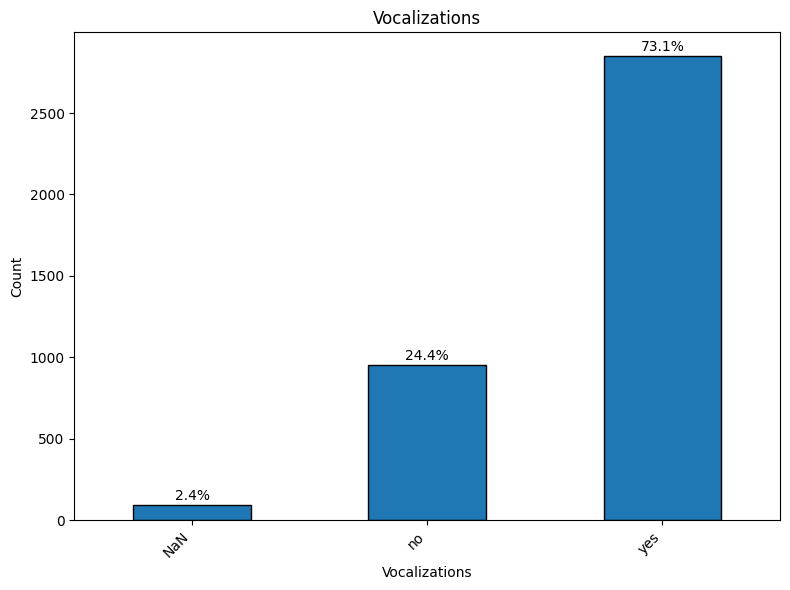

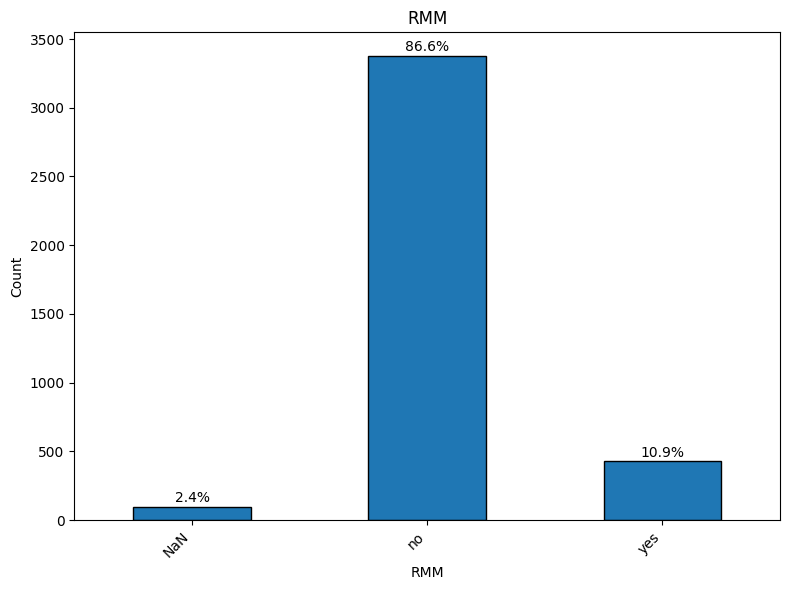

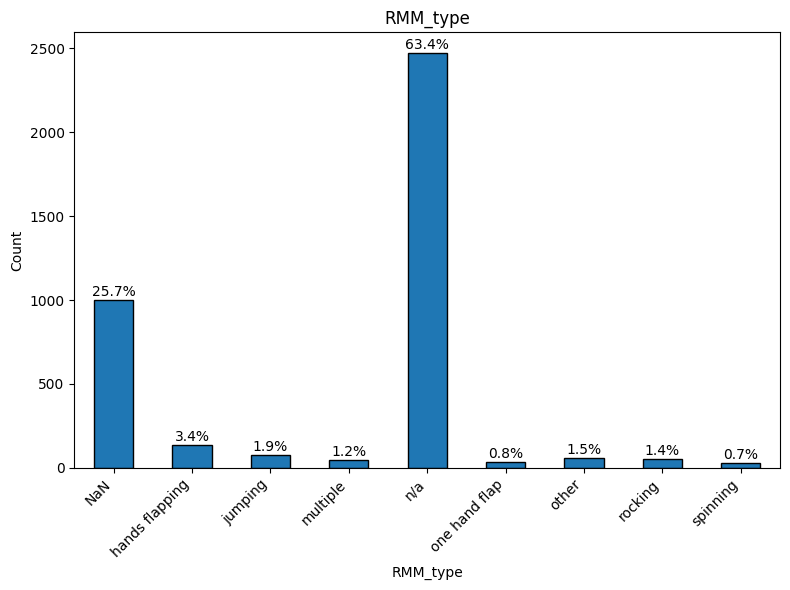

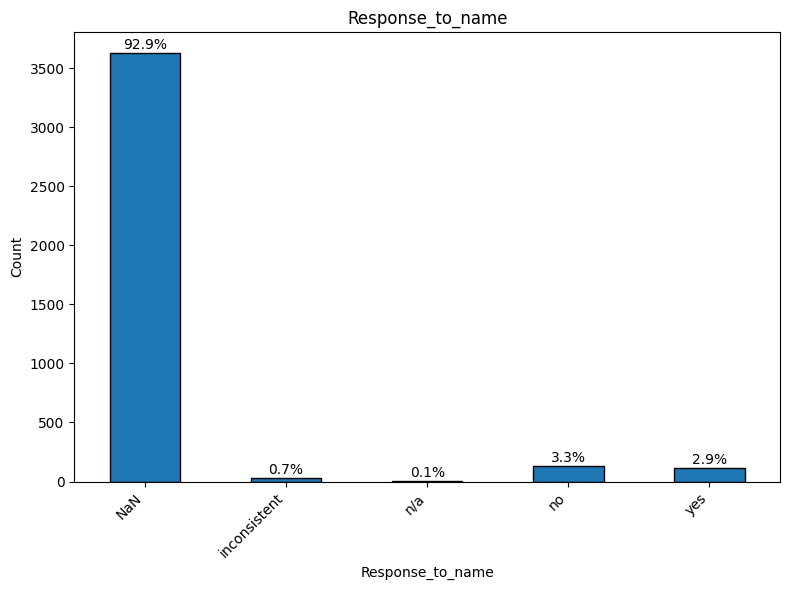

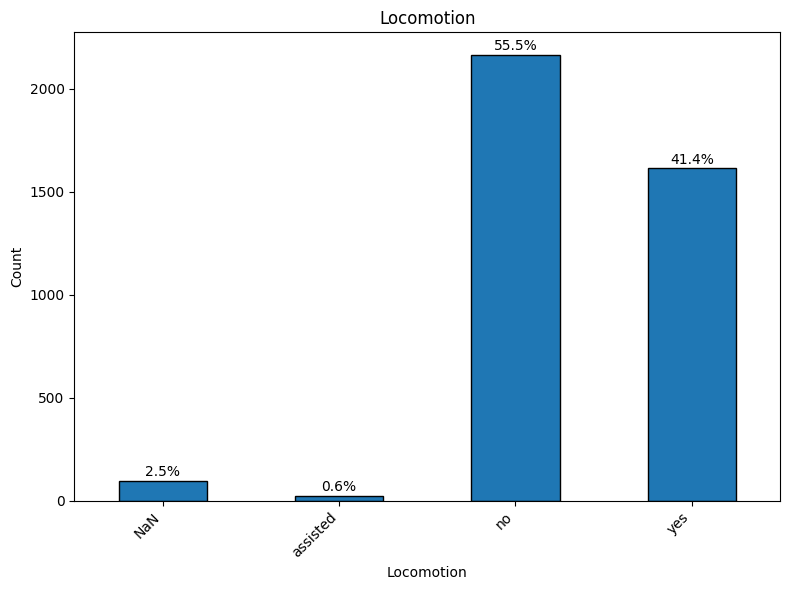

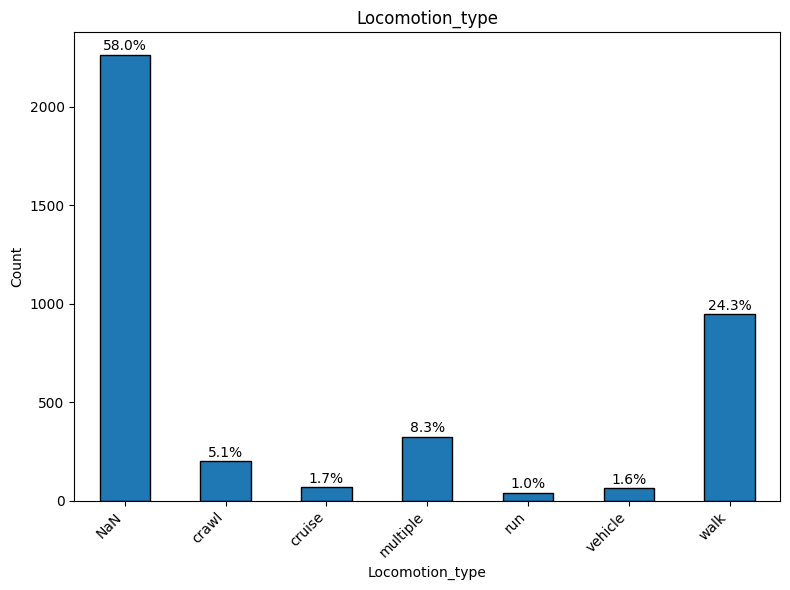

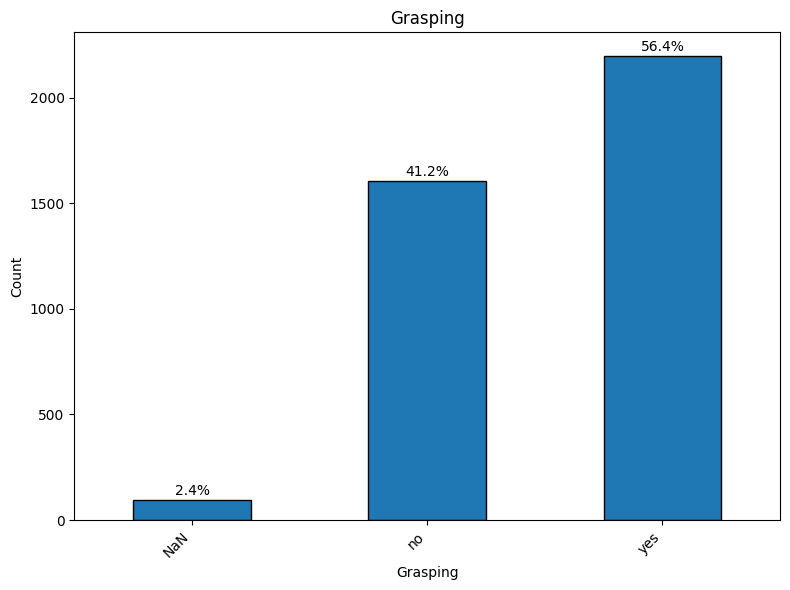

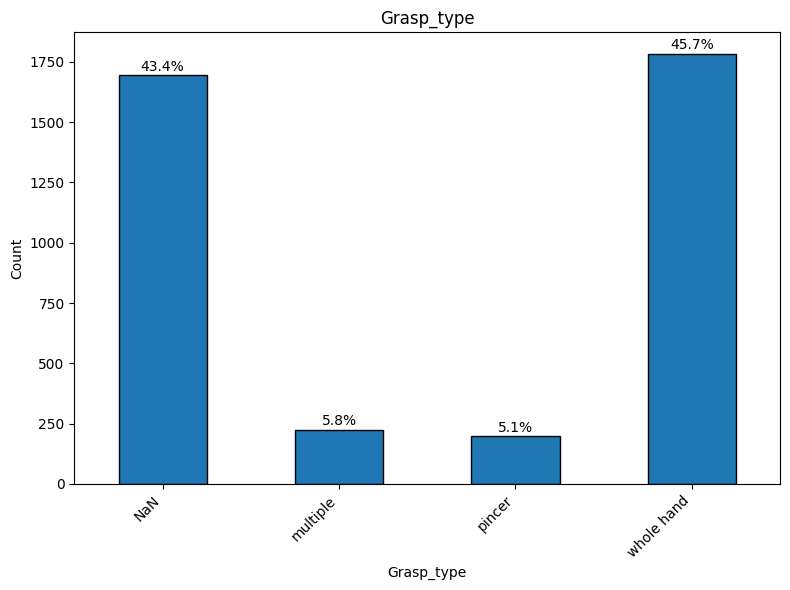

In [125]:
categorical_cols = [
    "Interaction_with_child",
    "#_people_interacting",
    "Child_constrained",
    # "Constraint_type",
    "Supports",
    "Support_type",
    "Gestures",
    "Gesture_type",
    "Vocalizations",
    "RMM",
    "RMM_type",
    "Response_to_name",
    "Locomotion",
    "Locomotion_type",
    "Grasping",
    "Grasp_type",
]

for i in categorical_cols:
    plot_bar_with_percent(df[i], title=i)

### Investigating NaNs

In [126]:
of_interest = ["Child_of_interest_clear", "#_adults_plot", "#_children_plot", "#_people_background_plot"]
categorical_cols = [
    "Interaction_with_child",
    "#_people_interacting",
    "Child_constrained",
    # "Constraint_type",
    "Supports",
    "Support_type",
    "Gestures",
    "Gesture_type",
    "Vocalizations",
    "RMM",
    "RMM_type",
    "Response_to_name",
    "Locomotion",
    "Locomotion_type",
    "Grasping",
    "Grasp_type",
]

In [127]:
# count NaNs per attribute per ID
nan_counts_id = df[of_interest].isna().groupby(df["ID"]).sum()
nan_counts_id["TotalMissing"] = nan_counts_id.sum(axis=1)
nan_counts_id = nan_counts_id.sort_values("TotalMissing", ascending=False)
nan_counts_id.loc[nan_counts_id["TotalMissing"] > 0]

,Child_of_interest_clear,#_adults_plot,#_children_plot,#_people_background_plot,TotalMissing
ID,,,,,
H7B1M3P5D9,37,36,36,36,145
N3C7S2N8O0,9,9,9,9,36
D7O9E3F9P9,7,7,7,7,28
A2L1R9Y7C8,7,7,7,7,28
B8I6G9P2G8,5,5,5,5,20
S7F0B6H3A3,4,4,4,4,16
T2H0J0N2Z5,3,3,3,3,12
I8T4E2J3M6,2,2,2,2,8
H9T5Y8D3A1,2,2,2,2,8


In [128]:
# count NaNs per attribute per file
nan_counts_file = df[of_interest].isna().groupby(df["SourceFile"]).sum()
nan_counts_file["TotalMissing"] = nan_counts_file.sum(axis=1)
nan_counts_file = nan_counts_file.sort_values("TotalMissing", ascending=False)
nan_counts_file.loc[nan_counts_file["TotalMissing"] == 4]

,Child_of_interest_clear,#_adults_plot,#_children_plot,#_people_background_plot,TotalMissing
SourceFile,,,,,
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/12-16 month videos/Nov 2018 (13m)/IMG_4907.MOV,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/A.L._Home_Videos_AMES_D7O9E3F9P9/34-38 month videos/IMG_1173.mov,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/C.S._Home_Videos_AMES_H7B1M3P5D9/34-38 months/IMG_9156.MOV,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/C.S._Home_Videos_AMES_H7B1M3P5D9 3/34-38 months/IMG_2337.mov,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.R._Home_Videos_AMES_H9T5Y8D3A1/12-16 Month Home Videos/Snapchat-1947936076.mp4,1,1,1,1,4
...,...,...,...,...,...
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/B.V._Home_Videos_AMES_B8I6G9P2G8/34-38 month videos/IMG_2500.mov,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.H._Home_Videos_AMES_N3C7S2N8O0 2/34-38 months/2018-05-10_101205.mp4,1,1,1,1,4
/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/L.H._Home_Videos_AMES_N3C7S2N8O0 2/34-38 months/2017-05-03_175139.mp4,1,1,1,1,4


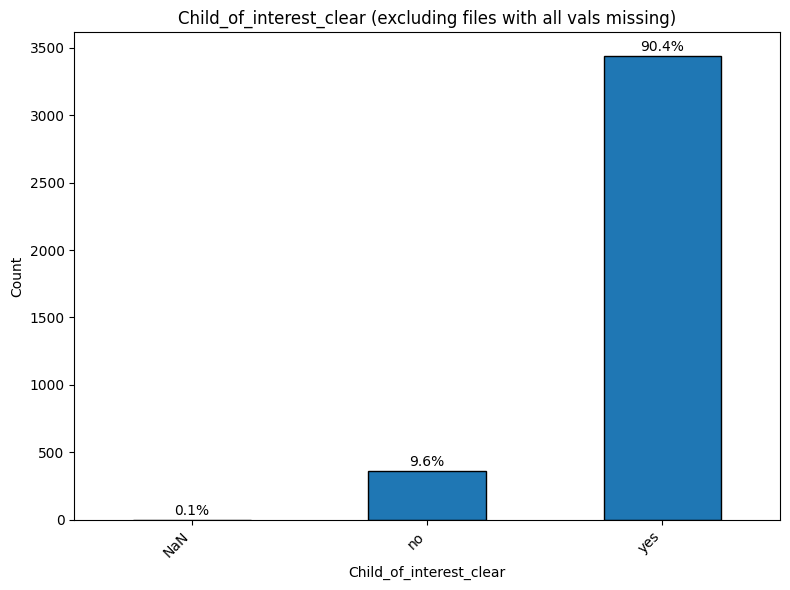

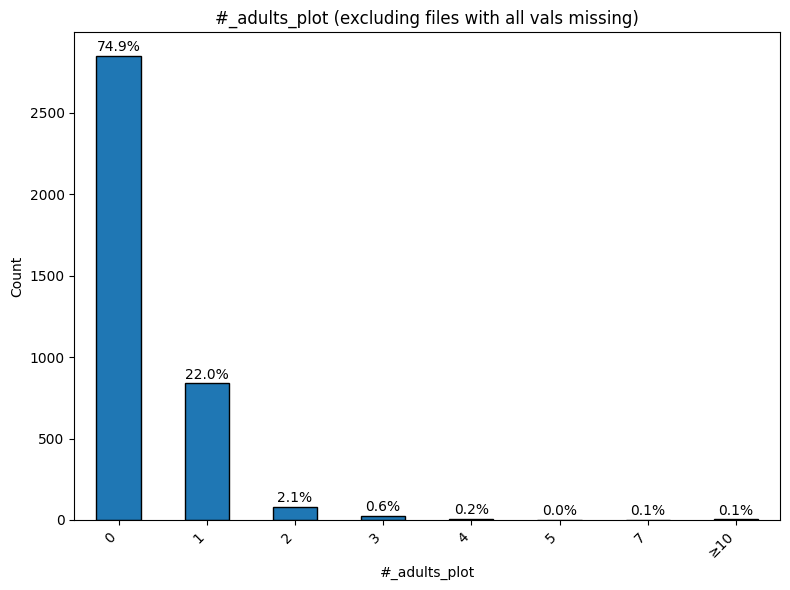

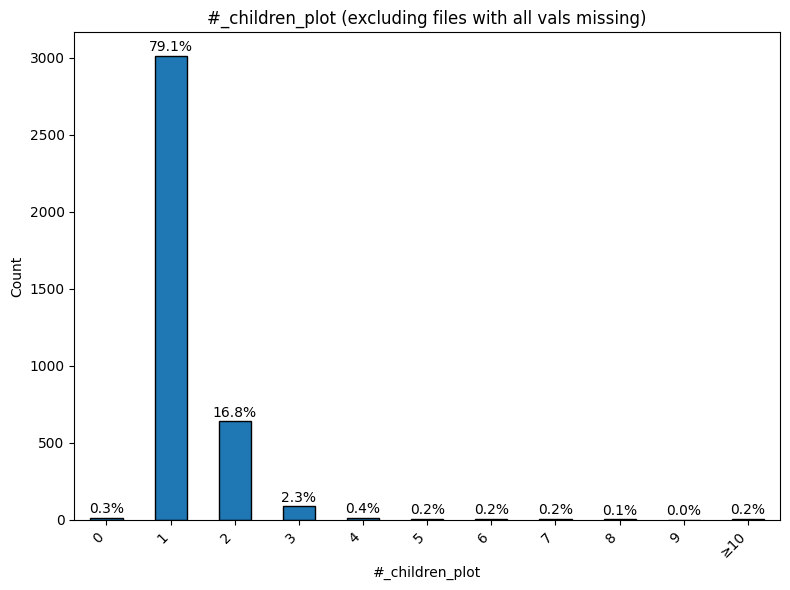

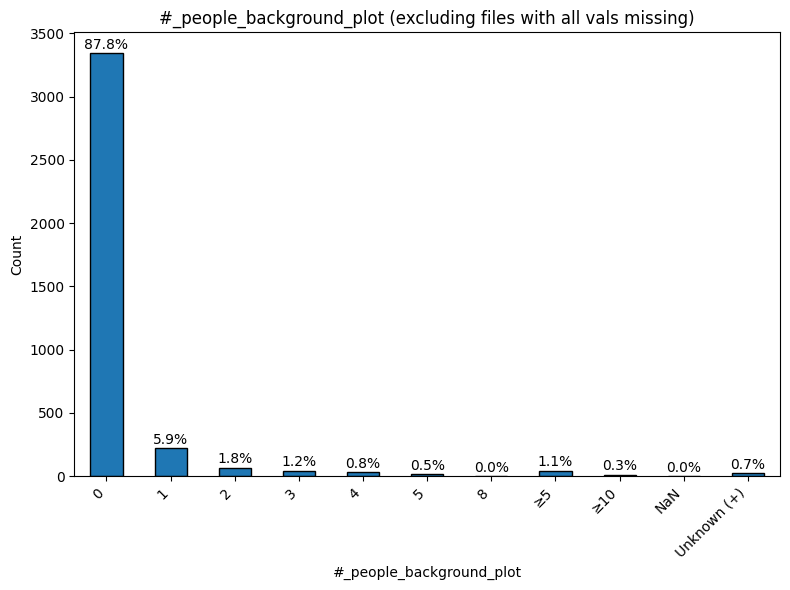

In [129]:
missing_all_attr = nan_counts_file.loc[nan_counts_file["TotalMissing"] == len(of_interest)].index.tolist()

for col in of_interest:
    subset = df.loc[~df["SourceFile"].isin(missing_all_attr), col]
    plot_bar_with_percent(subset, title=f"{col} (excluding files with all vals missing)")

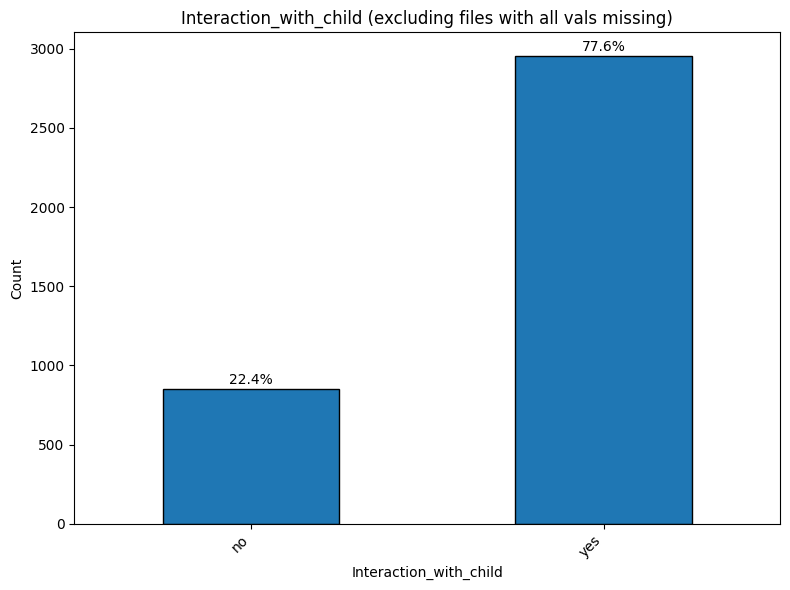

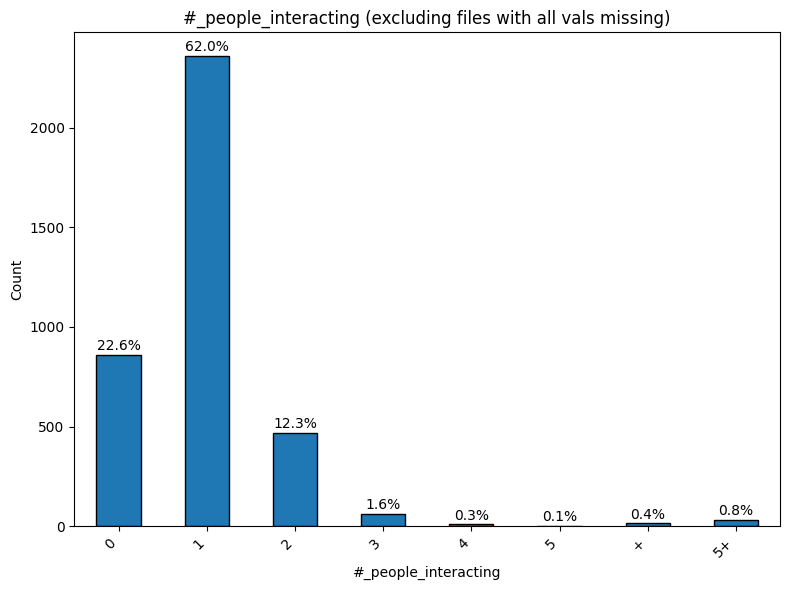

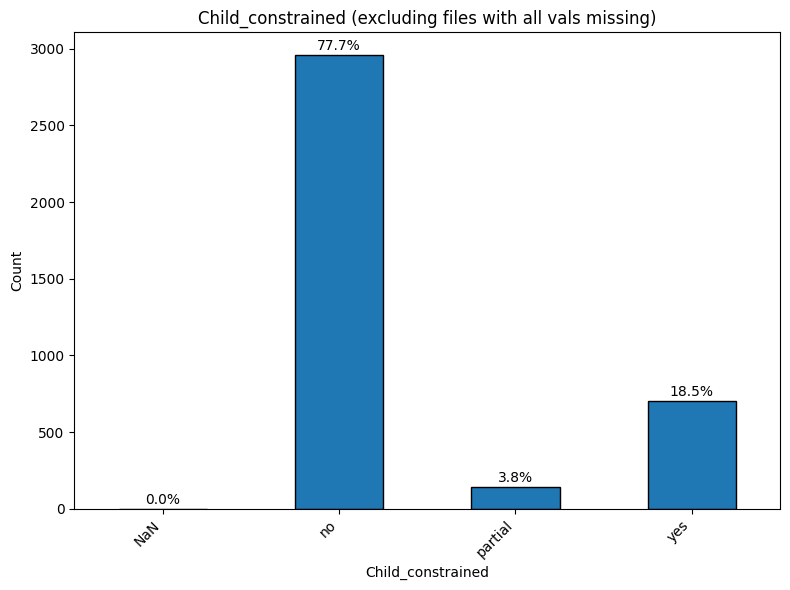

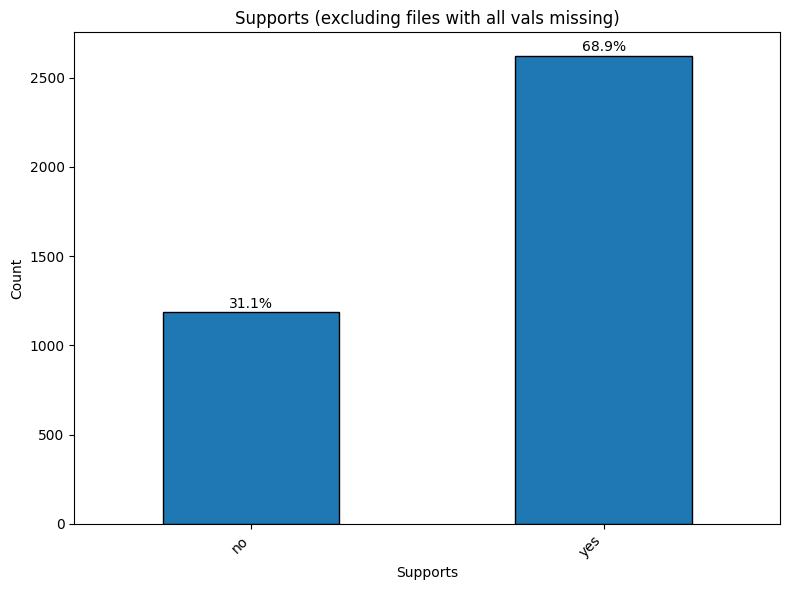

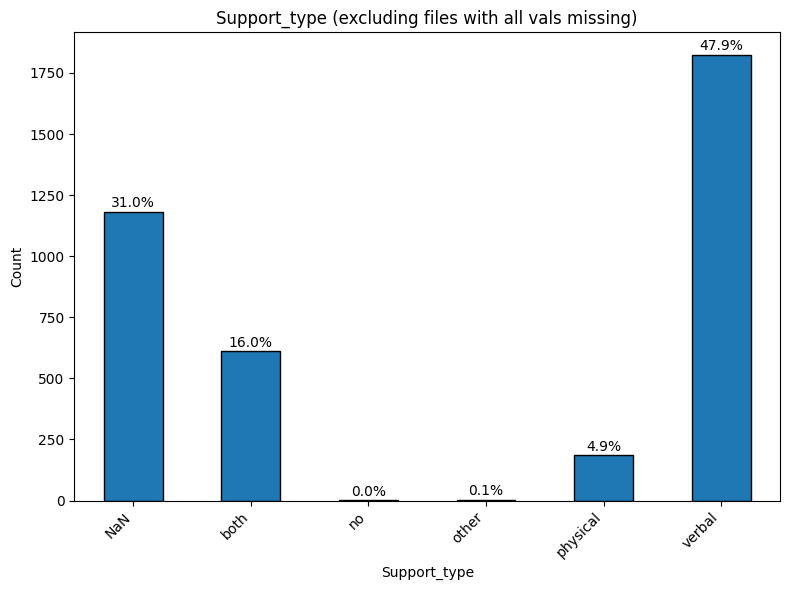

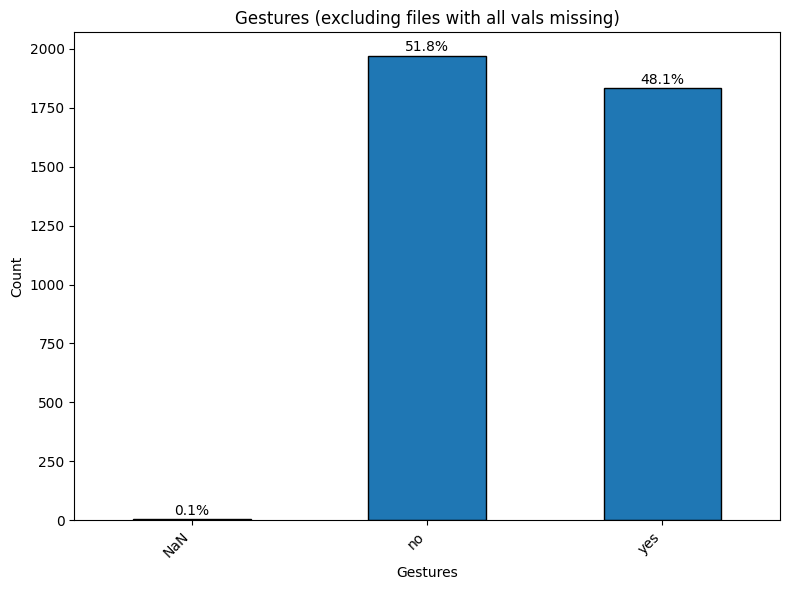

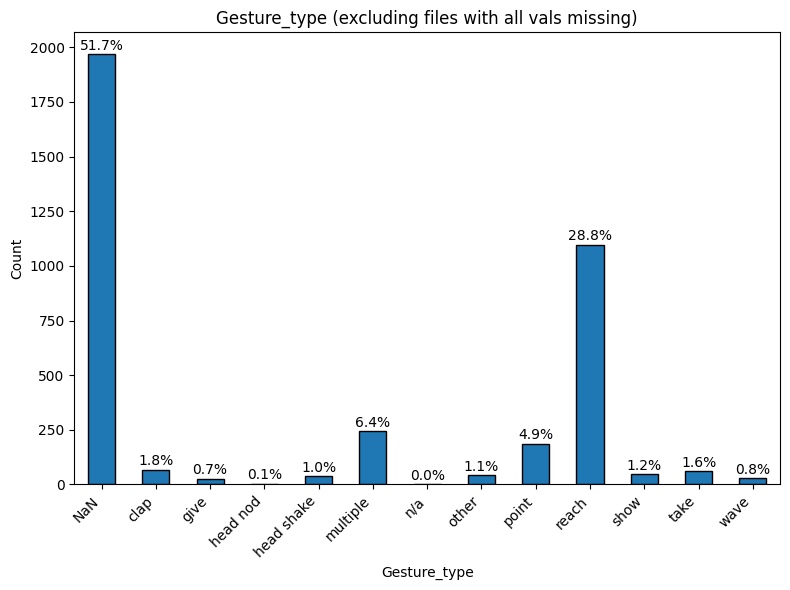

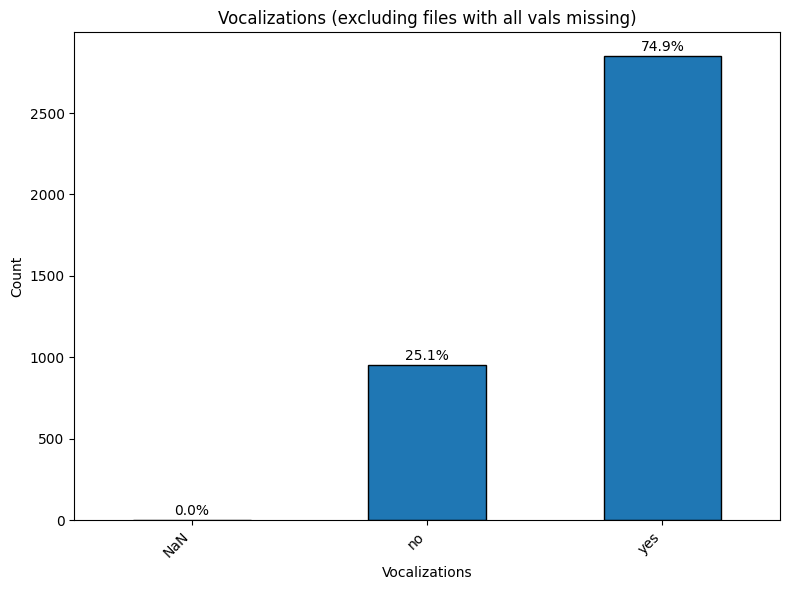

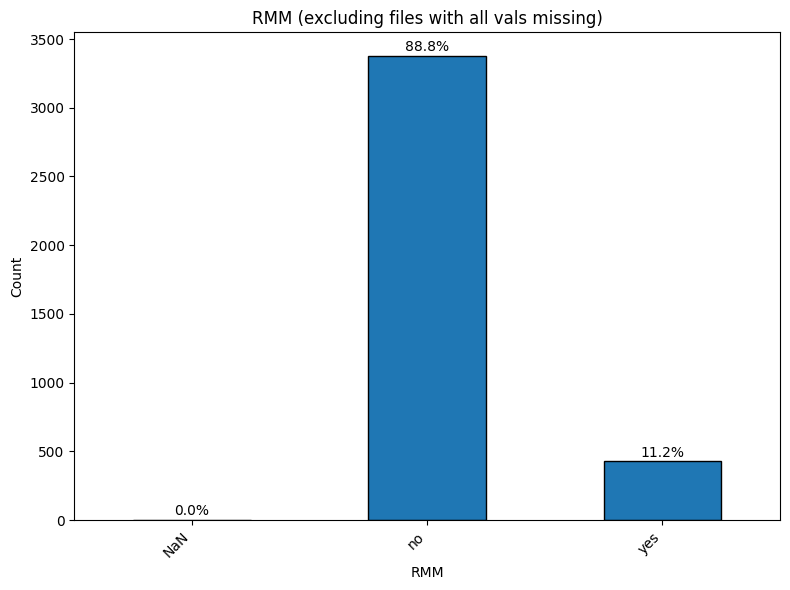

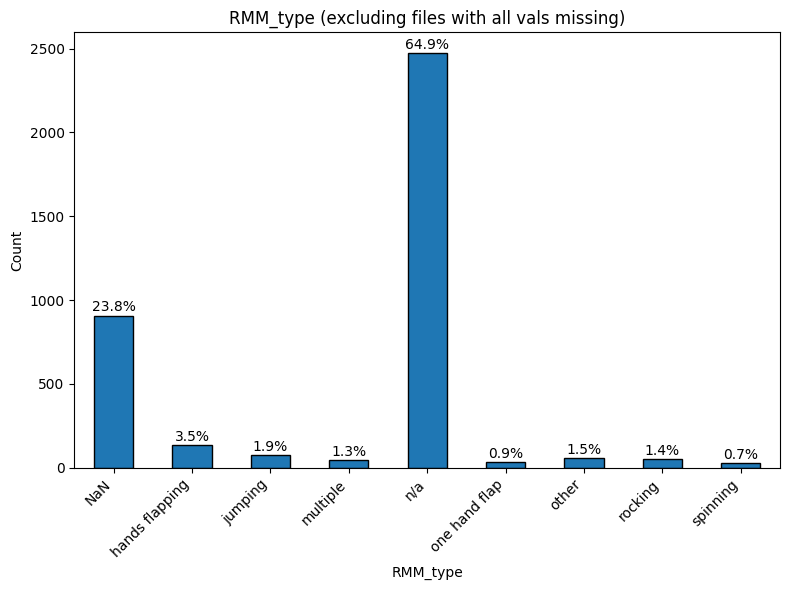

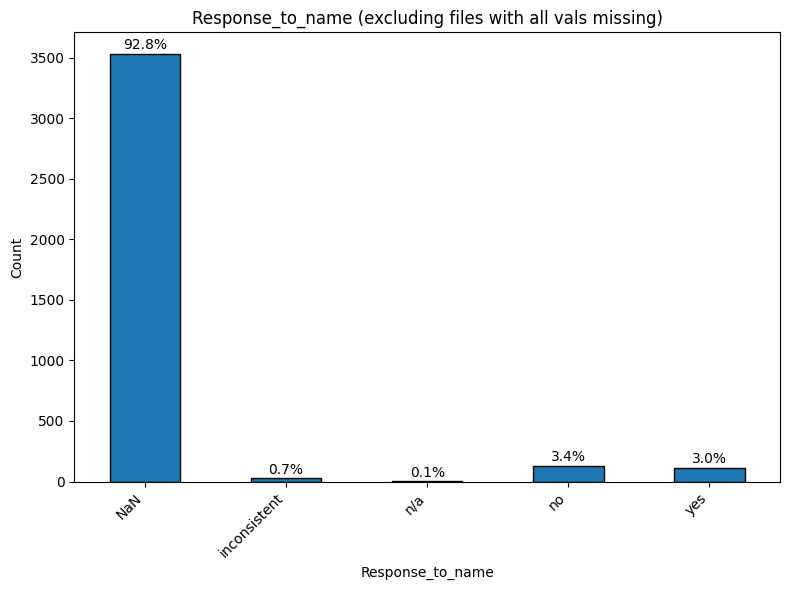

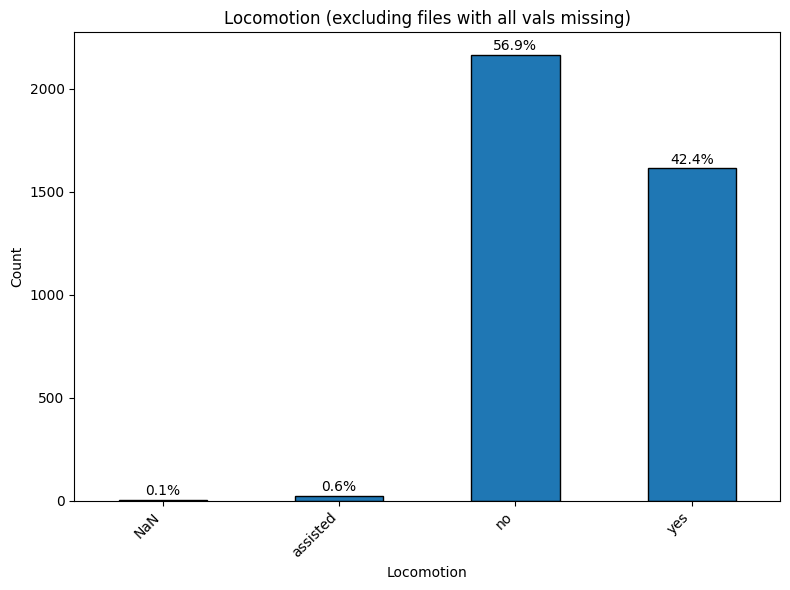

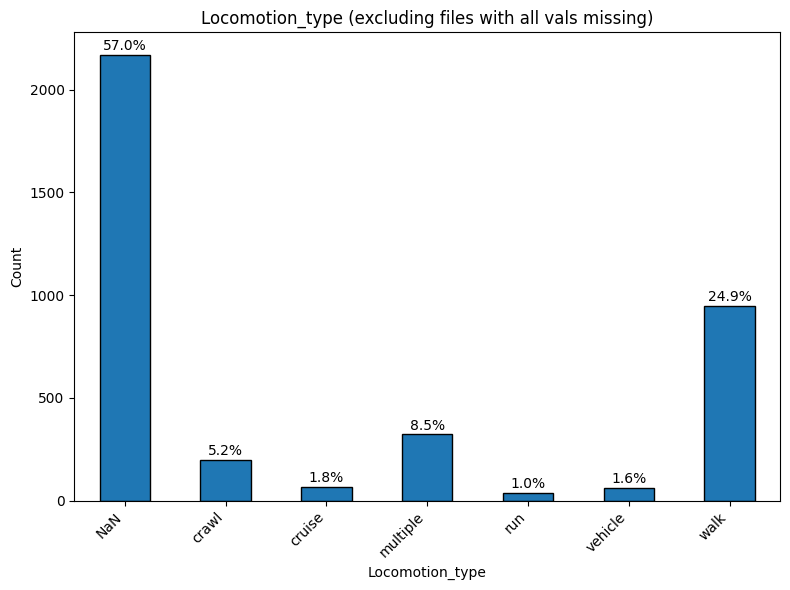

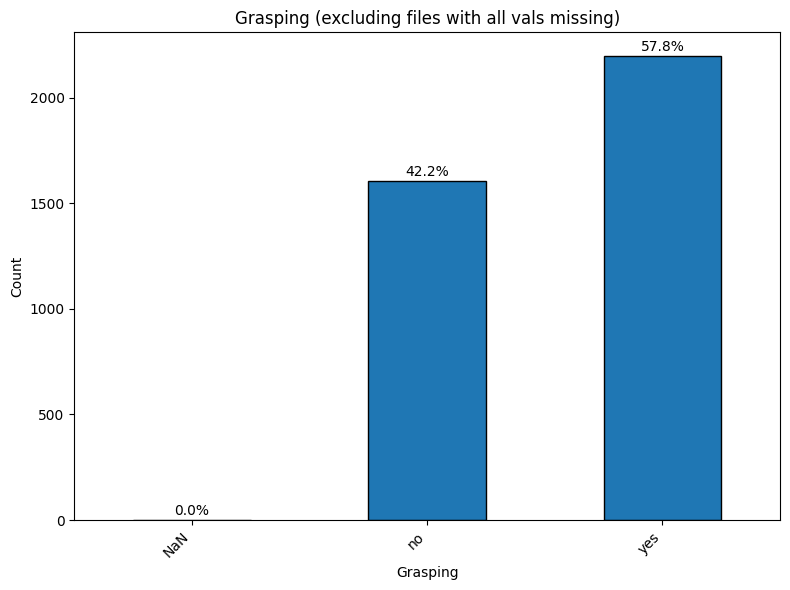

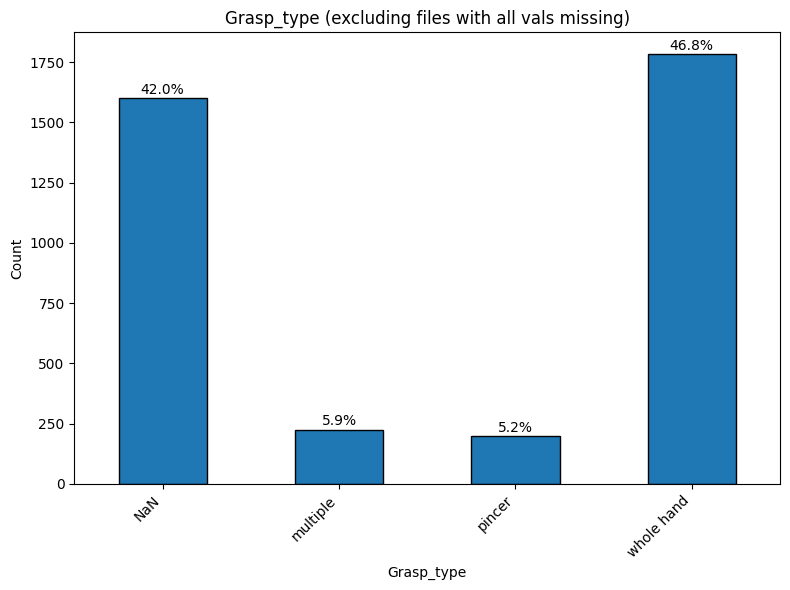

In [130]:
for col in categorical_cols:
    subset = df.loc[~df["SourceFile"].isin(missing_all_attr), col]
    plot_bar_with_percent(subset, title=f"{col} (excluding files with all vals missing)")

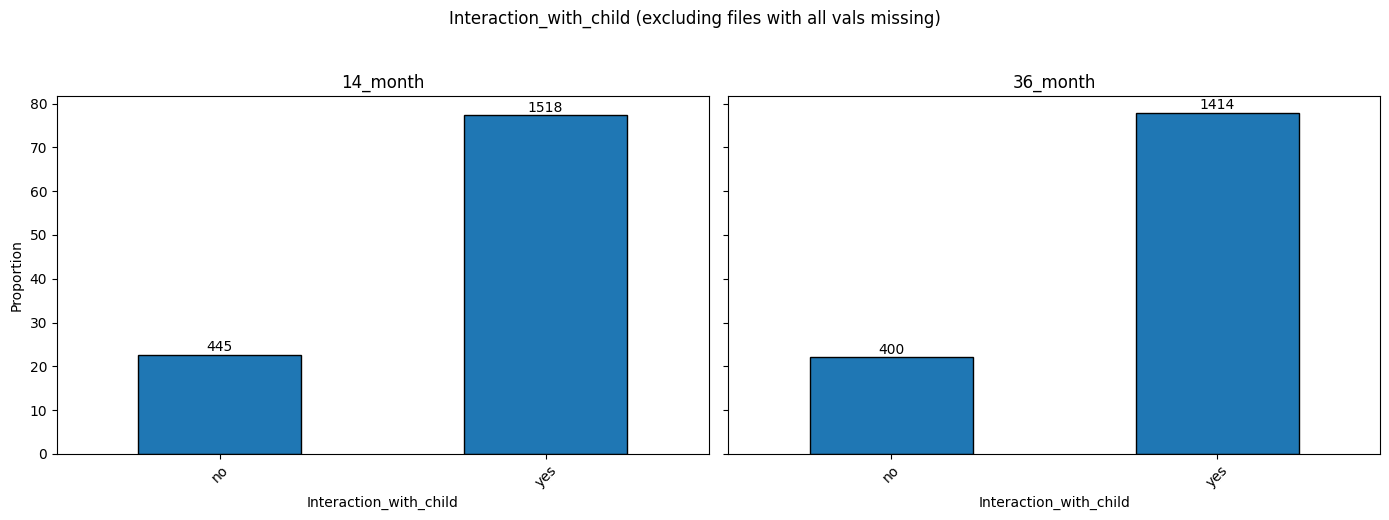

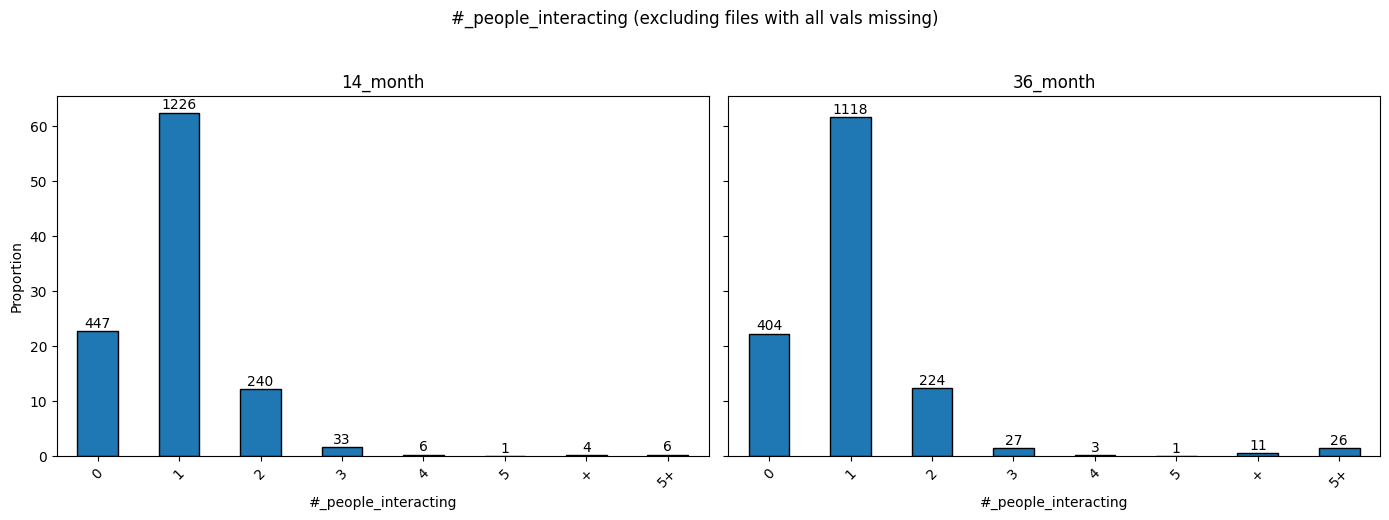

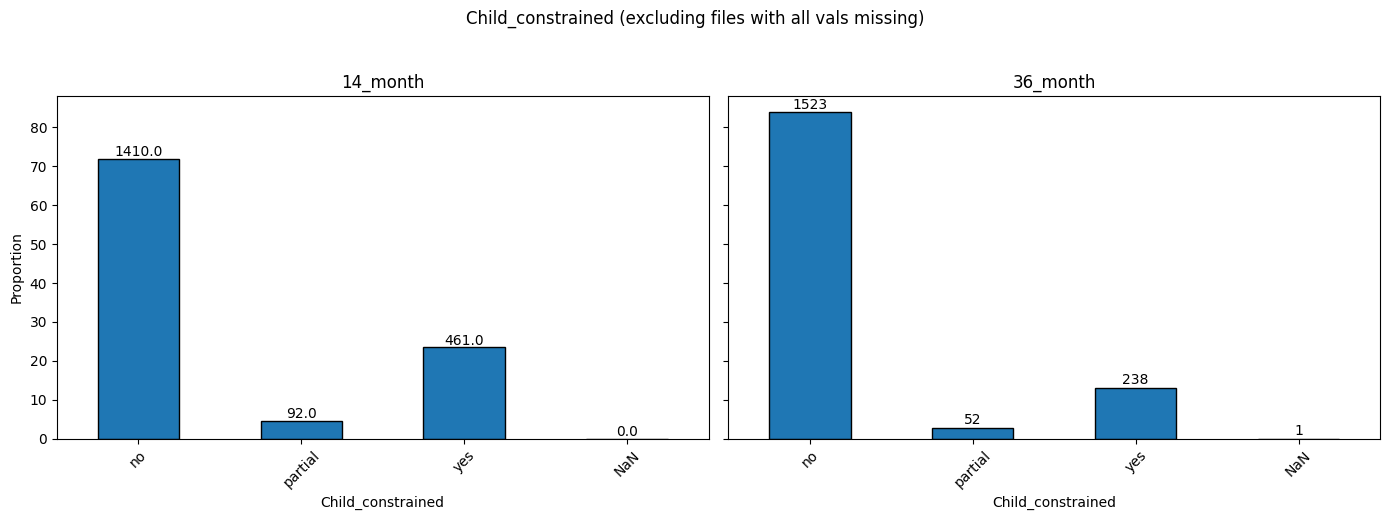

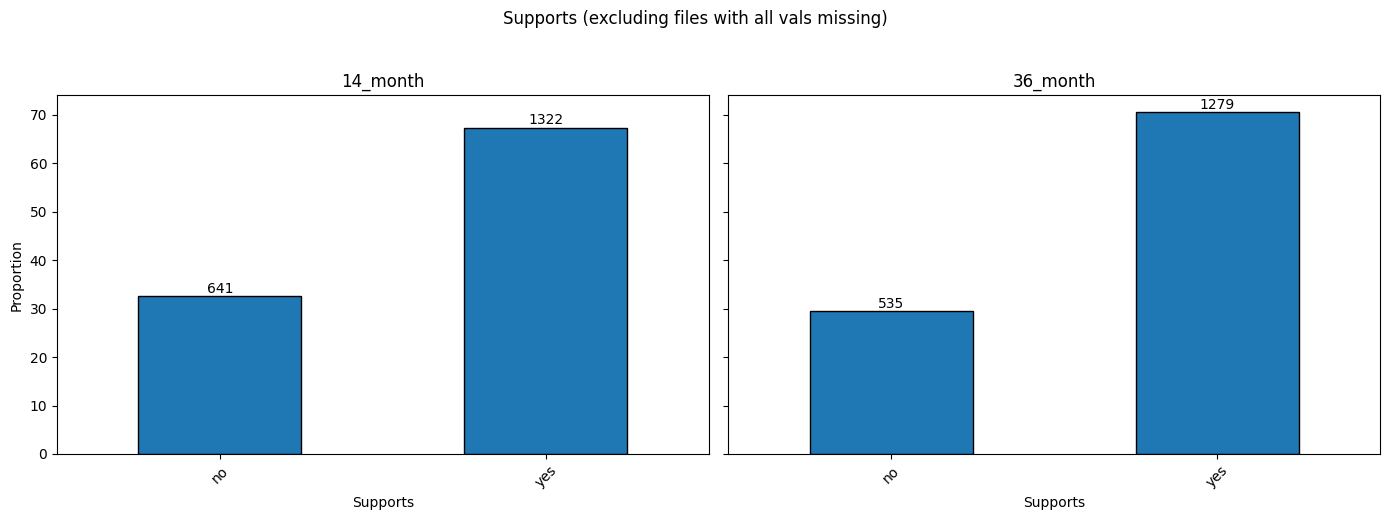

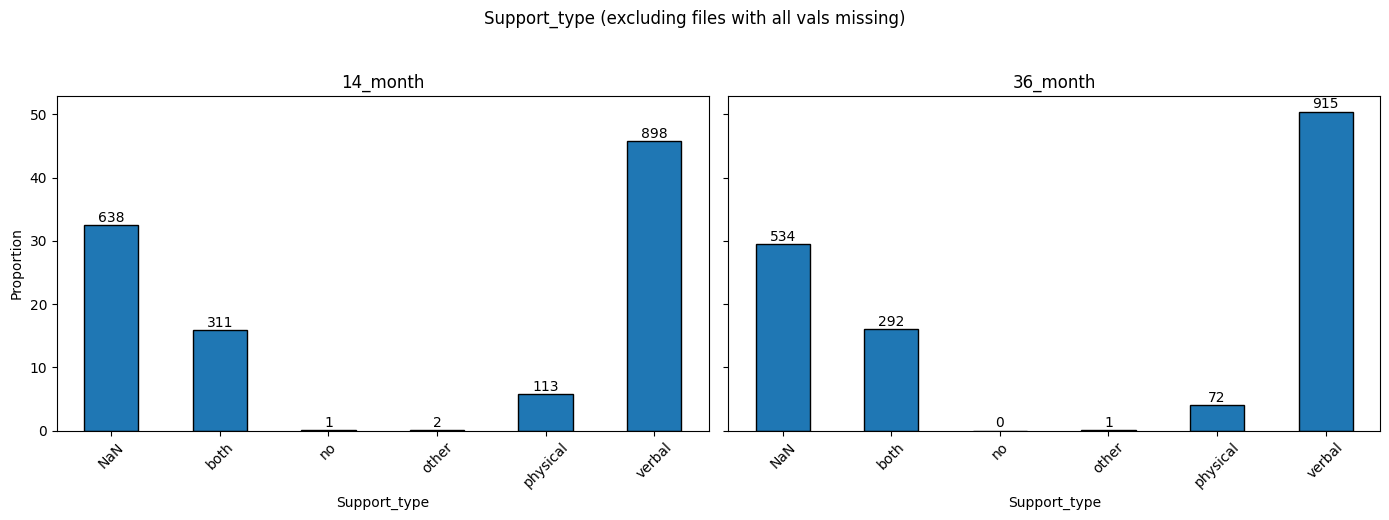

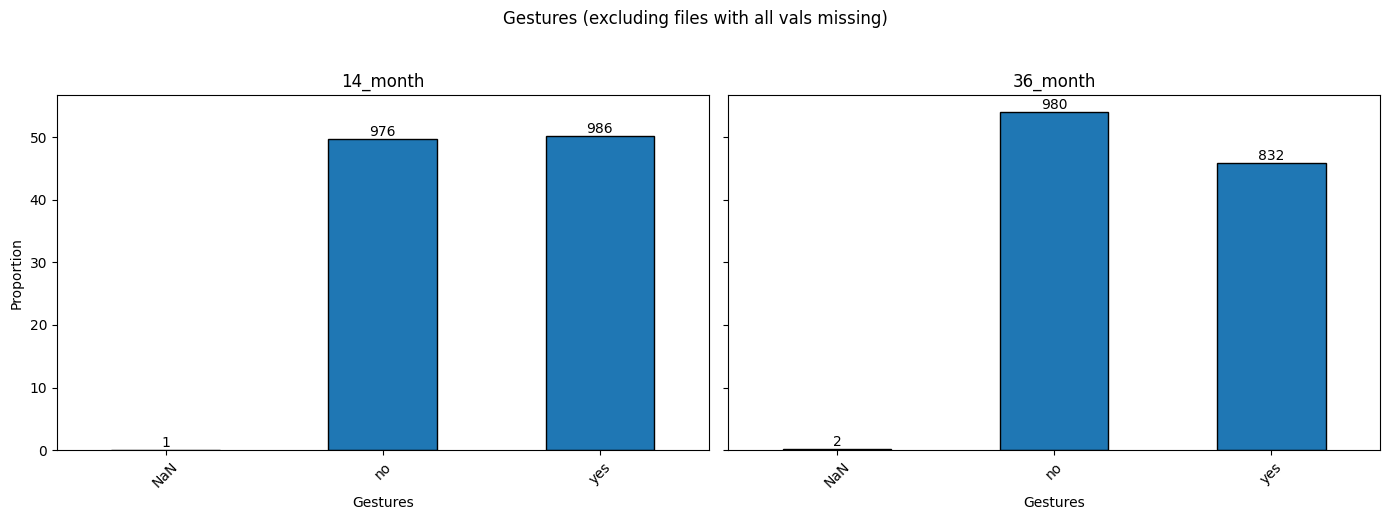

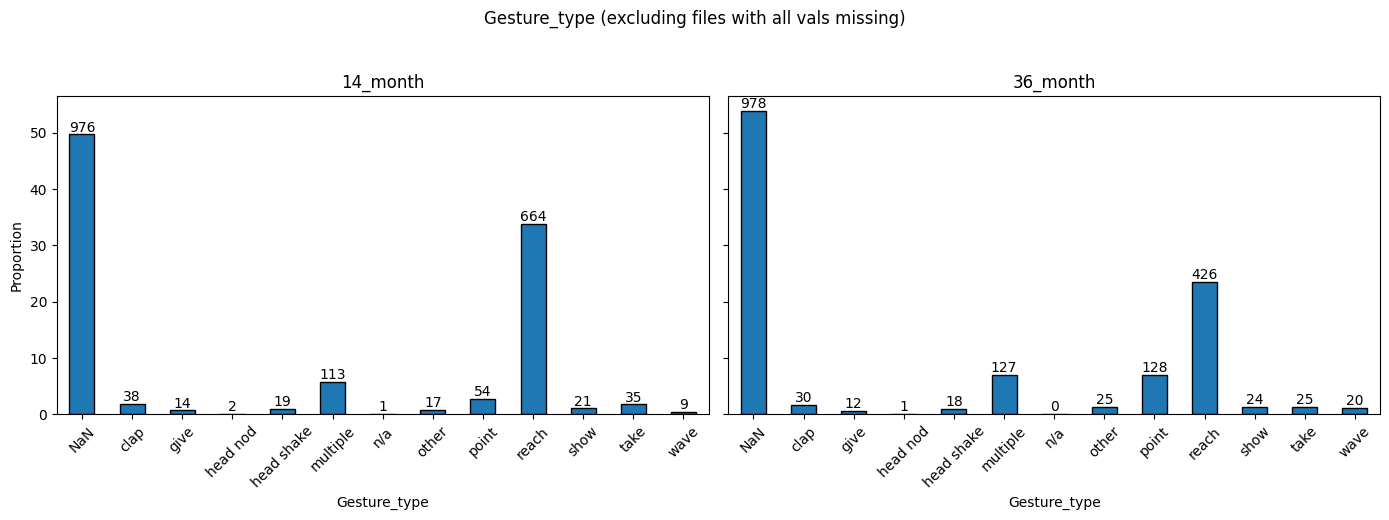

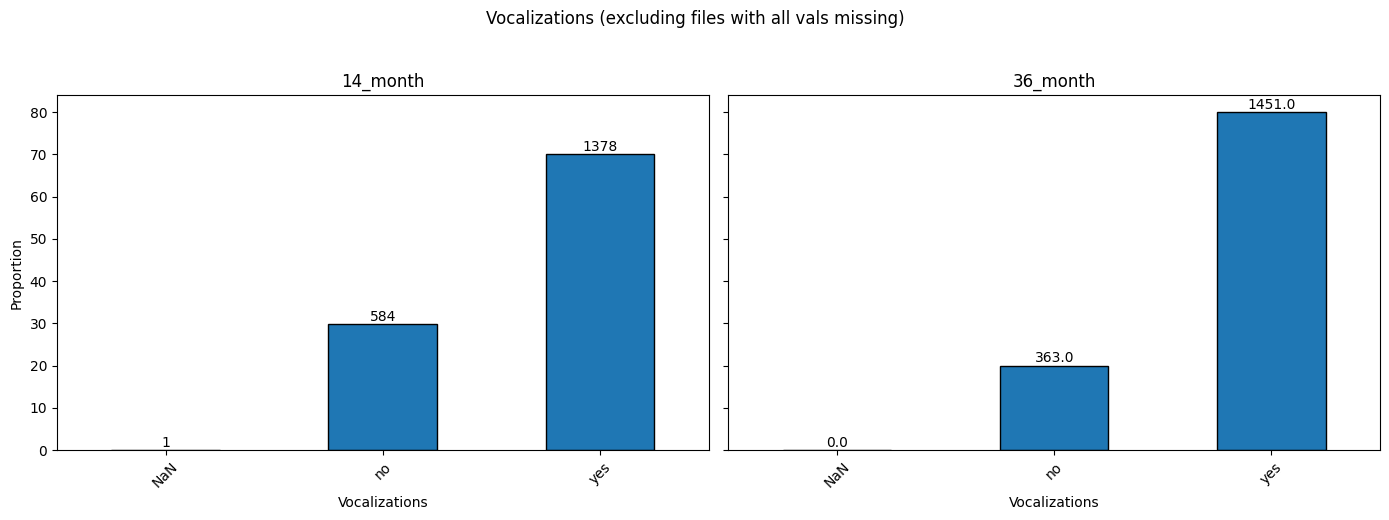

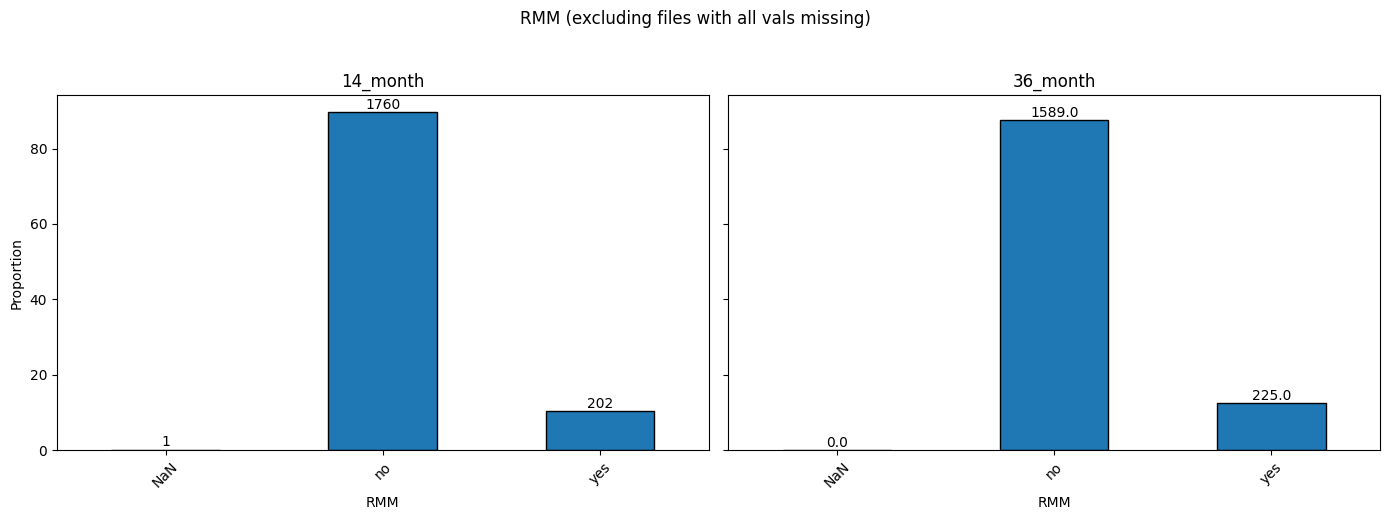

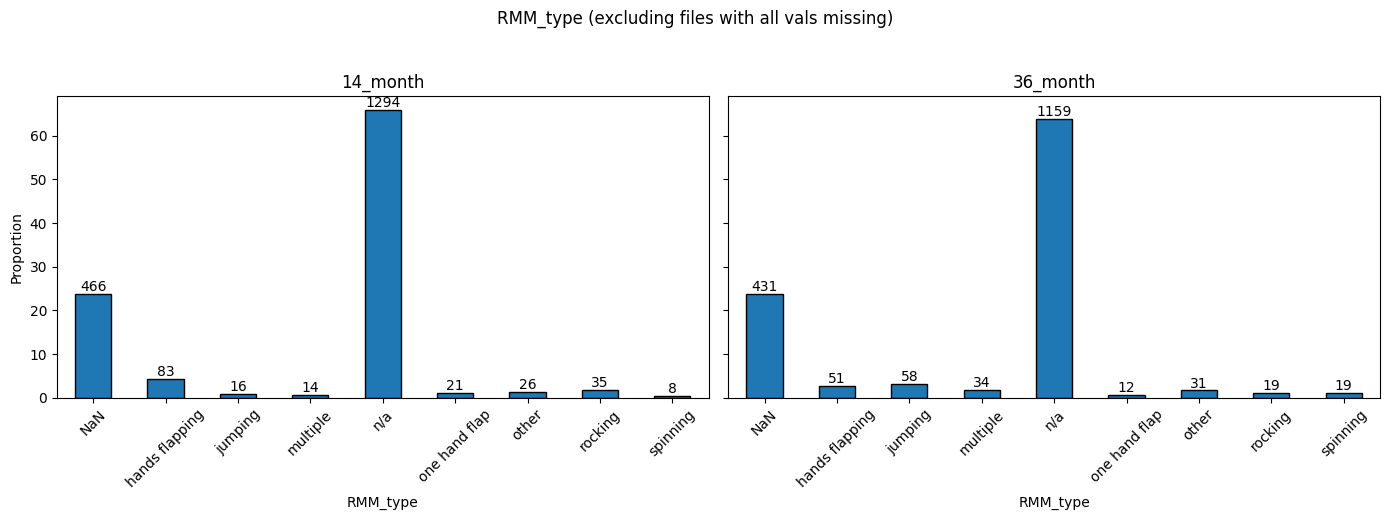

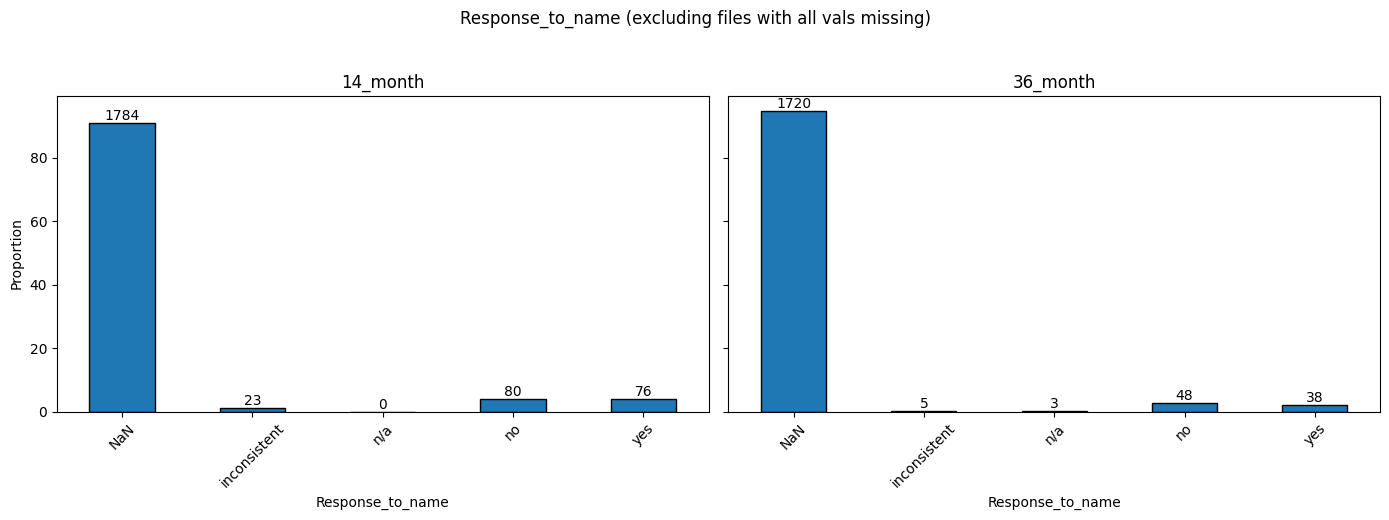

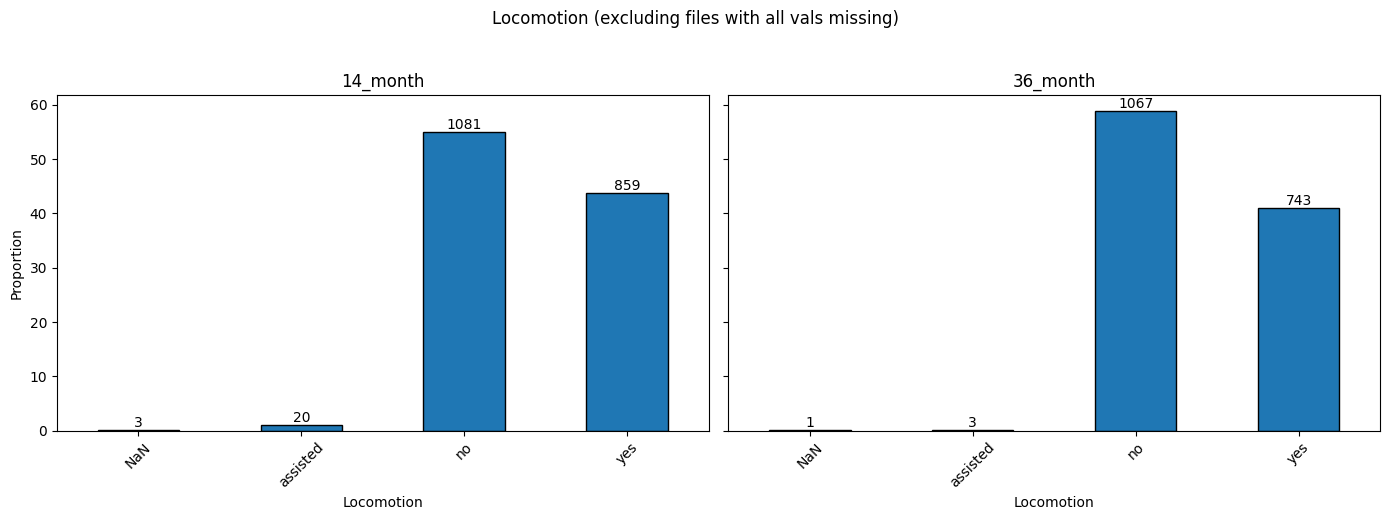

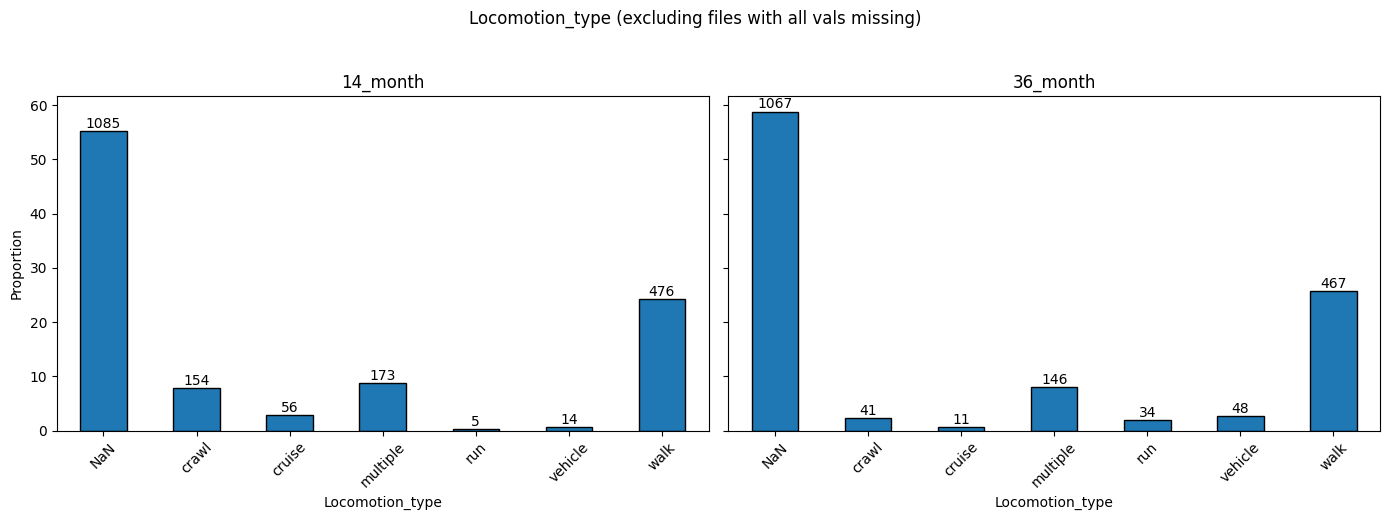

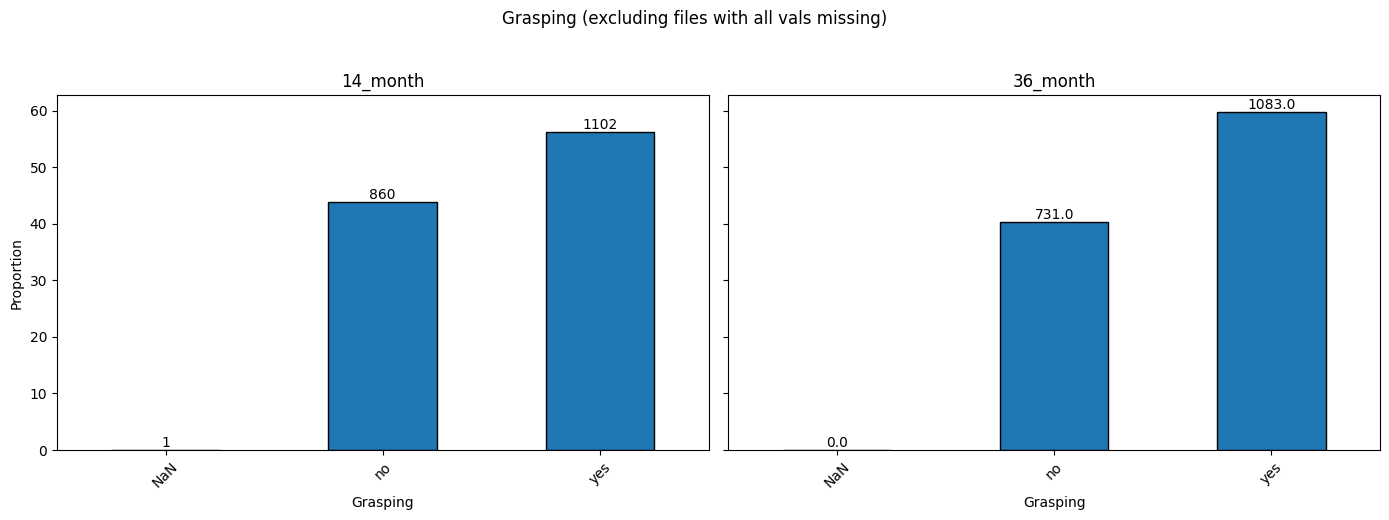

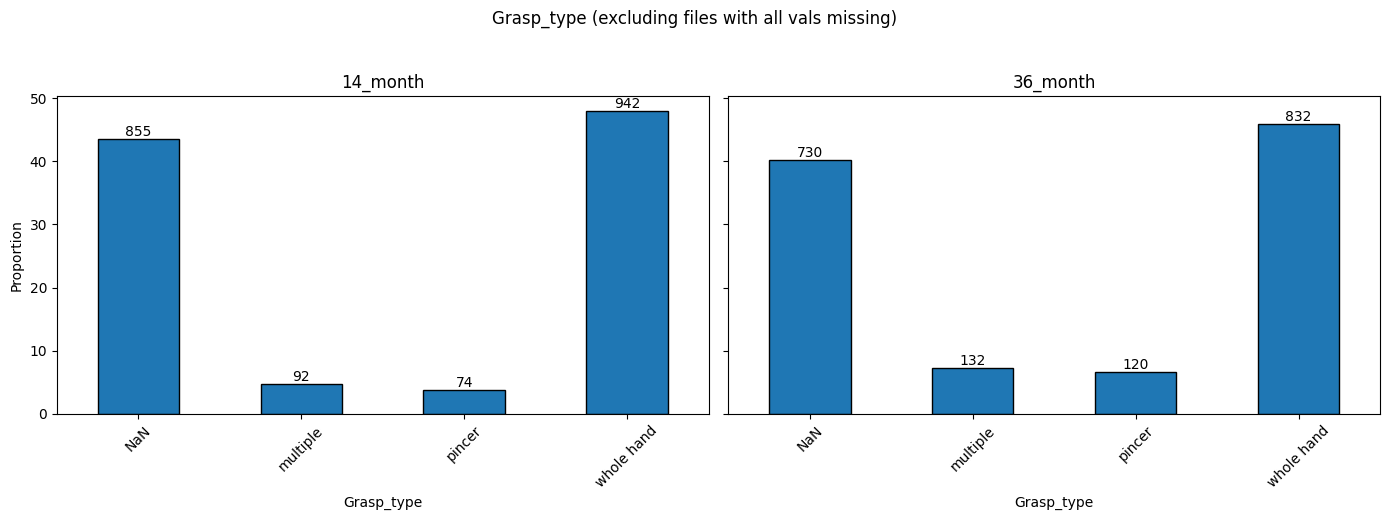

In [144]:
for col in categorical_cols:
    subset = df.loc[~df["SourceFile"].isin(missing_all_attr)]
    plot_by_time_point(subset, col, title=f"{col} (excluding files with all vals missing)", time_col="assumed_time_point", by_prop=True)

### Categorizations

In [18]:
from typing import Callable, Dict, Any, Optional

def build_quality_groups(
    df: pd.DataFrame,
    get_coder_path: Optional[Callable[[pd.DataFrame], Any]] = None,
    face_col: str = "Video_Quality_Child_Face_Visibility",
    body_col: str = "Video_Quality_Child_Body_Visibility",
) -> Dict[str, Any]:
    """
    Create groups of annotations based on face/body visibility quality.

    Ranges (inclusive/exclusive by design; non-overlapping):
      - perfect: >= 9
      - good:    6 <= x <= 8
      - medium:  4 <= x <  6  (face only, per your spec)
      - poor:    <  4

    Args:
        df: DataFrame with quality columns.
        get_coder_path: Optional transform applied to each filtered subset.
                        If None, the raw subset DataFrame is returned.
        face_col: Column name for face visibility quality.
        body_col: Column name for body visibility quality.

    Returns:
        dict[str, Any]: Keys are group names, values are either the
                        transformed result (via get_coder_path) or DataFrames.
    """
    # Coerce to numeric in case columns are strings
    local = df.copy()
    local[face_col] = pd.to_numeric(local[face_col], errors="coerce")
    local[body_col] = pd.to_numeric(local[body_col], errors="coerce")

    f = local[face_col]
    b = local[body_col]

    # Helper to apply callback or return subset
    def out(sub: pd.DataFrame):
        return get_coder_path(sub) if callable(get_coder_path) else sub

    groups = {}

    # 1) Face visibility
    groups["face_perfect"] = out(local[f >= 9])
    groups["face_good"]    = out(local[f.between(6, 8, inclusive="both")])
    groups["face_medium"]  = out(local[f.between(4, 6, inclusive="left")])  # 4 <= x < 6
    groups["face_poor"]    = out(local[f < 4])

    # 2) Body visibility (you specified perfect, good, poor)
    groups["body_perfect"] = out(local[b >= 9])
    groups["body_good"]    = out(local[b.between(6, 8, inclusive="both")])
    groups["body_poor"]    = out(local[b < 4])

    # 3) Face + Body combos
    groups["face_body_perfect"] = out(local[(f >= 9) & (b >= 9)])
    groups["face_body_good"]    = out(local[f.between(6, 8, inclusive="both") & b.between(6, 8, inclusive="both")])
    groups["face_body_poor"]    = out(local[(f < 4) & (b < 4)])

    return groups

In [19]:
categories = build_quality_groups(df)

In [25]:
face_body_poor = categories["face_body_poor"]

# if you already parsed '#_adults'/'#_children' into *_num
subset = face_body_poor[
    (face_body_poor["#_adults_num"] < 2) &
    # (face_body_poor["#_adults_num"] > 0) &
    (face_body_poor["#_children_num"] == 1) &
    (face_body_poor["#_people_background_num"] == 0)
]
subset.to_csv("/orcd/data/satra/001/users/brukew/sailsprep/subset_data/face_body_poor_one_child_1or0_adult.csv", index=False)
subset

,Coder,SourceFile,ID,FileName,Vid_duration,DOB,Vid_date,Age_in_months,time_point,Context,...,Notes,Vid_duration_s,#_adults_num,#_adults_plot,#_children_num,#_children_plot,#_people_background_num,#_people_background_plot,#_people_interacting_num,#_people_interacting_plot
32,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.L._Home_Videos_AMES_A6Y4Y7X2G1/34-38 month videos/10-31-2020.MOV,A6Y4Y7X2G1,10-31-2020.MOV,00:00:53.200000,2017-10-31,2020-10-31,36.013725,36_month,special occasion,...,NaN,53.2,1.0,1,1.0,1,0.0,0,1.0,1
37,AD,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.D._Home_Videos_AMES_C1I8N8L4Q4/34-38 month videos/9-30-2019.MOV,C1I8N8L4Q4,9-30-2019.MOV,00:00:11.500000,2016-03-20,2019-09-30,42.354593,NaN,general social communication interaction,...,NaN,11.5,0.0,0,1.0,1,0.0,0,1.0,1
112,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.T._Home_Videos_AMES_A5X1S7S1E7/34-38 month videos/078A361D-9F42-4FD2-9A10-8169514646CA2018-07-18_08-45-02_000.mov,A5X1S7S1E7,078A361D-9F42-4FD2-9A10-8169514646CA2018-07-18_08-45-02_000.mov,00:00:14,2015-09-29,2018-07-18,33.615365,36_month,toy play,...,NaN,14.0,1.0,1,1.0,1,0.0,0,1.0,1
155,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/I.M._Home_Videos_AMES_V9X2Q7S1E1/34-38 month videos/IMG_1658.mov,V9X2Q7S1E1,IMG_1658.mov,00:00:29.100000,2014-08-20,2017-06-05,33.516802,36_month,general social communication interaction,...,NaN,29.1,0.0,0,1.0,1,0.0,0,1.0,1
284,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/J.J._Home_Videos_AMES_W3P0N4W0X9/34-38 month videos/PXL_20210114_024323768.mp4,W3P0N4W0X9,PXL_20210114_024323768.mp4,00:00:19.300000,2018-03-31,2021-01-14,33.518171,36_month,general social communication interaction,...,NaN,19.3,1.0,1,1.0,1,0.0,0,1.0,1
371,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/S.V._Home_Videos_AMES_B1L0B3F6F1/34-38 month videos/August 15 2022.MOV,B1L0B3F6F1,August 15 2022.MOV,00:00:32.700000,2019-08-27,2022-08-15,35.619474,36_month,toy play,...,NaN,32.7,0.0,0,1.0,1,0.0,0,1.0,1
440,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/H.S-W._Home_Videos_AMES_B1S3L8Q7Y6/34-38 month videos/02082022(2).MOV,B1S3L8Q7Y6,02082022(2).MOV,00:00:21.300000,2019-03-11,2022-02-08,34.996612,36_month,motor play,...,NaN,21.3,0.0,0,1.0,1,0.0,0,1.0,1
541,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/G.S._Home_Videos_AMES_N3L7A1I2B9/34-38 month videos/20220420_113902.mp4,N3L7A1I2B9,20220420_113902.mp4,00:00:57.600000,2019-03-17,2022-04-20,37.130769,36_month,toy play,...,NaN,57.6,0.0,0,1.0,1,0.0,0,1.0,1
546,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/G.S._Home_Videos_AMES_N3L7A1I2B9/34-38 month videos/4.12.22.mp4,N3L7A1I2B9,4.12.22.mp4,00:00:05.800000,2019-03-17,2022-04-12,36.867935,36_month,general social communication interaction,...,NaN,5.8,1.0,1,1.0,1,0.0,0,1.0,1
557,BJH,/Volumes/T7 Shield/AMES_Phase_III/Phase_III_videos/M.B._Home_Videos_AMES_O6F1J9U1J2/34-38_month_videos/Feb 2020.mp4,O6F1J9U1J2,Feb 2020.mp4,00:00:20.500000,2017-04-13,2020-02-20,34.273819,36_month,general social communication interaction,...,video is an uncropped screen recording of Facebook page,20.5,0.0,0,1.0,1,0.0,0,1.0,1
